# Predicting Student Academic Success Using a Generalized Hybrid ML Framework
## Hybrid LSTM–Random Forest Model with 32-Week Temporal Sequences

### Master's Thesis Implementation (Updated - No completion_status)

**Author**: Advanced ML Framework for Educational Analytics  
**Purpose**: Predict student academic success using hybrid deep learning and ensemble methods  
**Data**: 32-week engagement sequences with demographic and academic features

**Note**: This version works without the 'completion_status' column

---

## 1. Environment Setup and Imports

In [1]:
# Install required packages if needed (uncomment as necessary)
# !pip install tensorflow scikit-learn pandas numpy matplotlib seaborn shap joblib --quiet

In [2]:
# Cell 1: Import all required libraries
import os
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from typing import Dict, List, Tuple, Optional, Any

# Machine Learning
from sklearn.model_selection import StratifiedKFold, GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, roc_curve, auc, f1_score, accuracy_score,
    precision_recall_curve, average_precision_score,
    confusion_matrix, classification_report, brier_score_loss,
    precision_score, recall_score
)
from sklearn.calibration import calibration_curve
from sklearn.utils.class_weight import compute_class_weight

# Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks, optimizers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.regularizers import l1_l2

# Optional: SHAP for interpretability
try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    print("SHAP not available. Install with: pip install shap")
    SHAP_AVAILABLE = False

# Optional: joblib for model saving
try:
    import joblib
except ImportError:
    import pickle as joblib

warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {len(tf.config.list_physical_devices('GPU')) > 0}")
if len(tf.config.list_physical_devices('GPU')) > 0:
    print(f"GPU Devices: {tf.config.list_physical_devices('GPU')}")
print(f"Python version: {pd.__version__}")

TensorFlow version: 2.20.0
GPU Available: False
Python version: 2.3.2


## 2. Configuration and Setup

In [3]:
# Cell 2: Set reproducibility seeds and project constants

# Reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)
os.environ['PYTHONHASHSEED'] = str(RANDOM_SEED)

# Project paths
DATASET_DIR = "./dataset32"
RESULTS_DIR = "./results32"
MODEL_DIR = os.path.join(RESULTS_DIR, "model")
PLOTS_DIR = os.path.join(RESULTS_DIR, "plots")

# Create directories if they don't exist
for directory in [RESULTS_DIR, MODEL_DIR, PLOTS_DIR]:
    os.makedirs(directory, exist_ok=True)
    print(f"Created/verified directory: {directory}")

# Model hyperparameters
SEQUENCE_LENGTH = 32  # 32 weeks
BATCH_SIZE = 32
EPOCHS = 100
EARLY_STOPPING_PATIENCE = 15
LEARNING_RATE = 0.001

# Expected columns (without completion_status)
EXPECTED_COLUMNS = [
    'student_id', 'institution', 'country_home', 'country_host', 
    'gender', 'age', 'language_proficiency', 'gpa_prev', 
    'attendance_rate', 'socio_econ_status', 'marital_status', 
    'teaching_style_difference', 'dropout', 'cultural_distance', 
    'support_program', 'target_success', 'weekly_engagement', 
    'subject_field'
]

print("\nConfiguration loaded successfully!")
print(f"Expected columns: {len(EXPECTED_COLUMNS)}")

Created/verified directory: ./results32
Created/verified directory: ./results32\model
Created/verified directory: ./results32\plots

Configuration loaded successfully!
Expected columns: 18


## 3. Data Loading and Validation

In [4]:
# Cell 3: Data loading functions with validation

def validate_dataset(df, dataset_name):
    """Validate dataset structure and content."""
    print(f"\nValidating {dataset_name}:")
    print(f"  Shape: {df.shape}")
    
    # Check for required columns
    missing_cols = set(EXPECTED_COLUMNS) - set(df.columns)
    extra_cols = set(df.columns) - set(EXPECTED_COLUMNS) - {'timestamp_created'}
    
    if missing_cols:
        print(f"  ⚠️ Missing columns: {missing_cols}")
    
    if extra_cols:
        print(f"  ℹ️ Extra columns (will be ignored): {extra_cols}")
    
    # Check for completion_status column
    if 'completion_status' in df.columns:
        print(f"  ⚠️ Found 'completion_status' column - will be dropped")
        df = df.drop('completion_status', axis=1)
    
    # Check target variable
    if 'target_success' in df.columns:
        print(f"  Target distribution: {df['target_success'].value_counts().to_dict()}")
    
    return df

def load_dataset(dataset_type: str) -> Dict[str, pd.DataFrame]:
    """Load train, validation, and test sets for a given dataset type."""
    data = {}
    for split in ['train', 'val', 'test']:
        file_path = os.path.join(DATASET_DIR, f"{dataset_type}_{split}_32w.csv")
        if os.path.exists(file_path):
            df = pd.read_csv(file_path)
            # Validate and clean dataset
            df = validate_dataset(df, f"{dataset_type}_{split}")
            data[split] = df
            print(f"✓ Loaded {dataset_type}_{split}: {df.shape}")
        else:
            print(f"✗ Warning: {file_path} not found")
    return data

# Load all datasets
print("="*60)
print("LOADING DATASETS")
print("="*60)

global_data = load_dataset('global')
static_data = load_dataset('static')
temporal_data = load_dataset('temporal')

# Check if any dataset was loaded
if not global_data:
    print("\n⚠️ No global dataset found. Attempting to use other datasets...")
    if static_data and temporal_data:
        print("Using static and temporal datasets instead.")
        # You can merge static and temporal if needed
    else:
        raise ValueError("No valid datasets found. Please check your data files.")

# Use global dataset as primary (or fallback to others)
if global_data and all(k in global_data for k in ['train', 'val', 'test']):
    train_df = global_data['train'].copy()
    val_df = global_data['val'].copy()
    test_df = global_data['test'].copy()
else:
    print("\n⚠️ Global dataset incomplete. Please ensure all splits are available.")
    # Fallback logic here if needed

print(f"\n" + "="*60)
print(f"DATASET SUMMARY")
print("="*60)
print(f"Train: {len(train_df)} samples")
print(f"Validation: {len(val_df)} samples")
print(f"Test: {len(test_df)} samples")
print(f"Total: {len(train_df) + len(val_df) + len(test_df)} samples")
print(f"\nAvailable columns: {list(train_df.columns)[:10]}...") # Show first 10 columns

LOADING DATASETS

Validating global_train:
  Shape: (1320, 19)
  Target distribution: {1: 819, 0: 501}
✓ Loaded global_train: (1320, 19)

Validating global_val:
  Shape: (165, 19)
  Target distribution: {1: 102, 0: 63}
✓ Loaded global_val: (165, 19)

Validating global_test:
  Shape: (165, 19)
  Target distribution: {1: 103, 0: 62}
✓ Loaded global_test: (165, 19)

Validating static_train:
  Shape: (1320, 18)
  ⚠️ Missing columns: {'weekly_engagement'}
  Target distribution: {1: 819, 0: 501}
✓ Loaded static_train: (1320, 18)

Validating static_val:
  Shape: (165, 18)
  ⚠️ Missing columns: {'weekly_engagement'}
  Target distribution: {1: 102, 0: 63}
✓ Loaded static_val: (165, 18)

Validating static_test:
  Shape: (165, 18)
  ⚠️ Missing columns: {'subject_field', 'weekly_engagement'}
  ℹ️ Extra columns (will be ignored): {'completion_status'}
  ⚠️ Found 'completion_status' column - will be dropped
  Target distribution: {1: 103, 0: 62}
✓ Loaded static_test: (165, 17)

Validating temporal_t

## 4. Data Preprocessing

In [5]:
# Cell 4: Data preprocessing functions

def parse_weekly_engagement(df: pd.DataFrame) -> pd.DataFrame:
    """Parse weekly_engagement column into individual week columns."""
    if 'weekly_engagement' in df.columns:
        # Check if it's already parsed
        if 'w1' not in df.columns:
            print("Parsing weekly_engagement column...")
            # Parse pipe-separated values
            engagement_data = df['weekly_engagement'].str.split('|', expand=True)
            
            # Handle cases where there might be fewer than 32 weeks
            n_weeks = min(engagement_data.shape[1], 32)
            if n_weeks < 32:
                print(f"⚠️ Found only {n_weeks} weeks of data, padding to 32...")
                for i in range(n_weeks, 32):
                    engagement_data[i] = 0
            
            engagement_data = engagement_data.iloc[:, :32].astype(float)
            engagement_data.columns = [f'w{i+1}' for i in range(32)]
            df = pd.concat([df, engagement_data], axis=1)
    return df

def identify_features(df: pd.DataFrame):
    """Identify and categorize features."""
    # Parse weekly engagement first
    df = parse_weekly_engagement(df)
    
    # Temporal features
    temporal_features = [f'w{i+1}' for i in range(32) if f'w{i+1}' in df.columns]
    
    # Numeric features (exclude age if it's missing)
    numeric_features = []
    potential_numeric = ['age', 'gpa_prev', 'attendance_rate', 'cultural_distance', 
                        'teaching_style_difference']
    for feat in potential_numeric:
        if feat in df.columns:
            numeric_features.append(feat)
    
    # Categorical features
    categorical_features = []
    potential_categorical = ['gender', 'language_proficiency', 'socio_econ_status',
                            'marital_status', 'support_program', 'subject_field',
                            'institution', 'country_home', 'country_host']
    for feat in potential_categorical:
        if feat in df.columns:
            categorical_features.append(feat)
    
    return df, temporal_features, numeric_features, categorical_features

def preprocess_features(df: pd.DataFrame):
    """Comprehensive preprocessing pipeline."""
    df = df.copy()
    
    # Remove completion_status if it exists
    if 'completion_status' in df.columns:
        df = df.drop('completion_status', axis=1)
    
    # Identify features
    df, temporal_features, numeric_features, categorical_features = identify_features(df)
    
    # Handle missing values
    if numeric_features:
        df[numeric_features] = df[numeric_features].fillna(df[numeric_features].median())
    
    if categorical_features:
        df[categorical_features] = df[categorical_features].fillna('Unknown')
    
    if temporal_features:
        df[temporal_features] = df[temporal_features].fillna(0)
    
    # Handle 'dropout' column if it exists (it might be boolean or numeric)
    if 'dropout' in df.columns:
        df['dropout'] = df['dropout'].fillna(0).astype(int)
    
    return df, temporal_features, numeric_features, categorical_features

# Preprocess all datasets
print("\nPreprocessing data...")
train_df, temporal_cols, numeric_cols, categorical_cols = preprocess_features(train_df)
val_df, _, _, _ = preprocess_features(val_df)
test_df, _, _, _ = preprocess_features(test_df)

print(f"\n" + "="*60)
print("FEATURE GROUPS")
print("="*60)
print(f"Temporal features: {len(temporal_cols)} - {temporal_cols[:5]}...")
print(f"Numeric features: {len(numeric_cols)} - {numeric_cols}")
print(f"Categorical features: {len(categorical_cols)} - {categorical_cols}")
print(f"\nTarget distribution in training set:")
print(train_df['target_success'].value_counts(normalize=True))
print(f"\nClass balance: {train_df['target_success'].mean():.2%} positive class")


Preprocessing data...
Parsing weekly_engagement column...
Parsing weekly_engagement column...
Parsing weekly_engagement column...

FEATURE GROUPS
Temporal features: 32 - ['w1', 'w2', 'w3', 'w4', 'w5']...
Numeric features: 5 - ['age', 'gpa_prev', 'attendance_rate', 'cultural_distance', 'teaching_style_difference']
Categorical features: 9 - ['gender', 'language_proficiency', 'socio_econ_status', 'marital_status', 'support_program', 'subject_field', 'institution', 'country_home', 'country_host']

Target distribution in training set:
target_success
1    0.620455
0    0.379545
Name: proportion, dtype: float64

Class balance: 62.05% positive class


## 5. Advanced Feature Engineering

In [6]:
# Cell 5: Advanced preprocessing class

class AdvancedPreprocessor:
    """Advanced preprocessing with proper train/test separation."""
    
    def __init__(self):
        self.numeric_scaler = StandardScaler()
        self.temporal_scaler = StandardScaler()
        self.label_encoders = {}
        self.one_hot_encoders = {}
        self.feature_names = []
        self.is_fitted = False
        
    def fit(self, df, temporal_cols, numeric_cols, categorical_cols):
        """Fit preprocessors on training data."""
        print("Fitting preprocessors...")
        
        # Fit scalers for numeric features if they exist
        if numeric_cols:
            self.numeric_scaler.fit(df[numeric_cols])
            print(f"  ✓ Fitted numeric scaler for {len(numeric_cols)} features")
        
        # Fit scaler for temporal features if they exist
        if temporal_cols:
            self.temporal_scaler.fit(df[temporal_cols])
            print(f"  ✓ Fitted temporal scaler for {len(temporal_cols)} features")
        
        # Fit encoders for categorical variables
        for col in categorical_cols:
            if col in df.columns:
                unique_values = df[col].nunique()
                
                if unique_values > 10:  # Use target encoding for high cardinality
                    # Calculate target mean for each category
                    target_means = df.groupby(col)['target_success'].mean()
                    self.label_encoders[col] = target_means.to_dict()
                    print(f"  ✓ Target encoding for {col} ({unique_values} unique values)")
                else:  # Use one-hot encoding for low cardinality
                    encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
                    encoder.fit(df[[col]])
                    self.one_hot_encoders[col] = encoder
                    print(f"  ✓ One-hot encoding for {col} ({unique_values} unique values)")
        
        self.is_fitted = True
        return self
    
    def transform(self, df, temporal_cols, numeric_cols, categorical_cols):
        """Transform data using fitted preprocessors."""
        if not self.is_fitted:
            raise ValueError("Preprocessor must be fitted before transform")
        
        df_processed = df.copy()
        
        # Scale numeric features
        if numeric_cols:
            df_processed[numeric_cols] = self.numeric_scaler.transform(df[numeric_cols])
        
        # Scale temporal features
        temporal_scaled = None
        if temporal_cols:
            temporal_scaled = self.temporal_scaler.transform(df[temporal_cols])
        
        # Encode categorical features
        feature_names = numeric_cols.copy() if numeric_cols else []
        
        for col in categorical_cols:
            if col in self.label_encoders:
                # Target encoding
                df_processed[f'{col}_encoded'] = df[col].map(self.label_encoders[col]).fillna(0.5)
                feature_names.append(f'{col}_encoded')
            elif col in self.one_hot_encoders:
                # One-hot encoding
                encoded = self.one_hot_encoders[col].transform(df[[col]])
                encoded_df = pd.DataFrame(
                    encoded,
                    columns=[f'{col}_{cat}' for cat in self.one_hot_encoders[col].categories_[0]],
                    index=df.index
                )
                df_processed = pd.concat([df_processed, encoded_df], axis=1)
                feature_names.extend(encoded_df.columns.tolist())
        
        # Add dropout if it exists as a feature
        if 'dropout' in df.columns and 'dropout' not in feature_names:
            feature_names.append('dropout')
        
        self.feature_names = feature_names
        
        return df_processed, temporal_scaled, feature_names

# Initialize and fit preprocessor
print("\n" + "="*60)
print("ADVANCED PREPROCESSING")
print("="*60)

preprocessor = AdvancedPreprocessor()
preprocessor.fit(train_df, temporal_cols, numeric_cols, categorical_cols)

# Transform all datasets
print("\nTransforming datasets...")
train_processed, train_temporal, static_features = preprocessor.transform(
    train_df, temporal_cols, numeric_cols, categorical_cols
)
val_processed, val_temporal, _ = preprocessor.transform(
    val_df, temporal_cols, numeric_cols, categorical_cols
)
test_processed, test_temporal, _ = preprocessor.transform(
    test_df, temporal_cols, numeric_cols, categorical_cols
)

print(f"\nProcessed feature dimensions:")
print(f"  Static features: {len(static_features)}")
print(f"  Temporal shape: {train_temporal.shape if train_temporal is not None else 'None'}")
print(f"  Sample static features: {static_features[:5]}...")


ADVANCED PREPROCESSING
Fitting preprocessors...
  ✓ Fitted numeric scaler for 5 features
  ✓ Fitted temporal scaler for 32 features
  ✓ One-hot encoding for gender (4 unique values)
  ✓ One-hot encoding for language_proficiency (5 unique values)
  ✓ One-hot encoding for socio_econ_status (3 unique values)
  ✓ One-hot encoding for marital_status (3 unique values)
  ✓ One-hot encoding for support_program (5 unique values)
  ✓ One-hot encoding for subject_field (8 unique values)
  ✓ One-hot encoding for institution (6 unique values)
  ✓ Target encoding for country_home (13 unique values)
  ✓ One-hot encoding for country_host (3 unique values)

Transforming datasets...

Processed feature dimensions:
  Static features: 44
  Temporal shape: (1320, 32)
  Sample static features: ['age', 'gpa_prev', 'attendance_rate', 'cultural_distance', 'teaching_style_difference']...


## 6. Prepare Data for Models

In [7]:
# Cell 6: Prepare data for models

def prepare_model_data(df_processed, temporal_data, static_features):
    """Prepare data in the format needed for models."""
    # Initialize outputs
    X_temporal = None
    X_static = None
    
    # Temporal data for LSTM (reshape to 3D: samples, timesteps, features)
    if temporal_data is not None:
        X_temporal = temporal_data.reshape(-1, 32, 1)  # Single feature per timestep
    
    # Static data for Random Forest and hybrid model
    if static_features:
        # Check which features actually exist in the processed dataframe
        available_features = [f for f in static_features if f in df_processed.columns]
        if available_features:
            X_static = df_processed[available_features].values
        else:
            print("⚠️ Warning: No static features found, creating dummy features")
            X_static = np.zeros((len(df_processed), 1))
    
    # Target variable
    y = df_processed['target_success'].values
    
    return X_temporal, X_static, y

# Prepare training data
print("\nPreparing data for models...")
X_train_temporal, X_train_static, y_train = prepare_model_data(
    train_processed, train_temporal, static_features
)
X_val_temporal, X_val_static, y_val = prepare_model_data(
    val_processed, val_temporal, static_features
)
X_test_temporal, X_test_static, y_test = prepare_model_data(
    test_processed, test_temporal, static_features
)

# Calculate class weights for imbalanced data
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = {i: w for i, w in enumerate(class_weights)}

print(f"\n" + "="*60)
print("DATA SHAPES")
print("="*60)
print(f"Training:")
print(f"  Temporal: {X_train_temporal.shape if X_train_temporal is not None else 'None'}")
print(f"  Static: {X_train_static.shape if X_train_static is not None else 'None'}")
print(f"  Target: {y_train.shape}")
print(f"\nValidation:")
print(f"  Temporal: {X_val_temporal.shape if X_val_temporal is not None else 'None'}")
print(f"  Static: {X_val_static.shape if X_val_static is not None else 'None'}")
print(f"\nTest:")
print(f"  Temporal: {X_test_temporal.shape if X_test_temporal is not None else 'None'}")
print(f"  Static: {X_test_static.shape if X_test_static is not None else 'None'}")
print(f"\nClass weights: {class_weight_dict}")
print(f"Class distribution: {np.bincount(y_train.astype(int))}")


Preparing data for models...

DATA SHAPES
Training:
  Temporal: (1320, 32, 1)
  Static: (1320, 44)
  Target: (1320,)

Validation:
  Temporal: (165, 32, 1)
  Static: (165, 44)

Test:
  Temporal: (165, 32, 1)
  Static: (165, 44)

Class weights: {0: np.float64(1.3173652694610778), 1: np.float64(0.8058608058608059)}
Class distribution: [501 819]


## 7. Build LSTM Model

In [8]:
# Cell 7: Build LSTM model

def build_lstm_model(sequence_length=32, n_features=1, learning_rate=0.001):
    """Build advanced LSTM model with regularization."""
    
    # Clear any existing models
    tf.keras.backend.clear_session()
    
    # Temporal input
    temporal_input = layers.Input(shape=(sequence_length, n_features), name='temporal_input')
    
    # LSTM layers with regularization
    x = layers.LSTM(64, return_sequences=True, 
                   kernel_regularizer=l1_l2(l1=0.01, l2=0.01),
                   recurrent_regularizer=l1_l2(l1=0.01, l2=0.01),
                   name='lstm_1')(temporal_input)
    x = layers.BatchNormalization(name='bn_1')(x)
    x = layers.Dropout(0.3, name='dropout_1')(x)
    
    x = layers.LSTM(32, return_sequences=False,
                   kernel_regularizer=l1_l2(l1=0.01, l2=0.01),
                   name='lstm_2')(x)
    x = layers.BatchNormalization(name='bn_2')(x)
    x = layers.Dropout(0.3, name='dropout_2')(x)
    
    # Dense layers
    lstm_embedding = layers.Dense(16, activation='relu', name='lstm_embedding')(x)
    lstm_output = layers.Dense(1, activation='sigmoid', name='lstm_output')(lstm_embedding)
    
    # Create model
    model = models.Model(inputs=temporal_input, outputs=[lstm_output, lstm_embedding])
    
    # Compile with custom optimizer
    optimizer = optimizers.Adam(learning_rate=learning_rate)
    model.compile(
        optimizer=optimizer,
        loss={'lstm_output': 'binary_crossentropy'},
        metrics={'lstm_output': ['accuracy', tf.keras.metrics.AUC(name='auc')]}
    )
    
    return model

# Build LSTM model only if we have temporal data
if X_train_temporal is not None:
    print("\nBuilding LSTM model...")
    lstm_model = build_lstm_model(
        sequence_length=32,
        n_features=1,
        learning_rate=LEARNING_RATE
    )
    
    print("\nLSTM Model Architecture:")
    lstm_model.summary()
else:
    print("⚠️ No temporal data available, skipping LSTM model")
    lstm_model = None


Building LSTM model...


LSTM Model Architecture:


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ temporal_input (InputLayer)          │ (None, 32, 1)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 32, 64)              │          16,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bn_1 (BatchNormalization)            │ (None, 32, 64)              │             256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_2 (LSTM)                        │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bn_2 (BatchNormalization)            │ (None, 32)                  │             128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_embedding (Dense)               │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_output (Dense)                  │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 30,241 (118.13 KB)

 Trainable params: 30,049 (117.38 KB)

 Non-trainable params: 192 (768.00 B)

## 8. Train LSTM Model

In [10]:
# Cell 8: Train LSTM model

import tensorflow as tf
from tensorflow.keras.optimizers import Adam

# Custom weighted binary crossentropy loss function
def weighted_binary_crossentropy(class_weights):
    """
    Creates a weighted binary crossentropy loss function
    class_weights: dict like {0: weight_for_class_0, 1: weight_for_class_1}
    """
    def loss(y_true, y_pred):
        # Ensure y_true is float32
        y_true = tf.cast(y_true, tf.float32)
        
        # Convert class weights to float32 tensors
        weight_0 = tf.constant(class_weights[0], dtype=tf.float32)
        weight_1 = tf.constant(class_weights[1], dtype=tf.float32)
        
        # Calculate weights based on true labels
        weights = tf.where(
            tf.equal(y_true, 1.0),
            weight_1,
            weight_0
        )
        
        # Calculate binary crossentropy
        bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
        
        # Apply weights
        weighted_bce = bce * weights
        
        return tf.reduce_mean(weighted_bce)
    
    return loss

# Dummy loss for embedding output
def embedding_loss(y_true, y_pred):
    return tf.constant(0.0, dtype=tf.float32)

if lstm_model is not None and X_train_temporal is not None:
    
    # Recompile model with custom loss for multi-output support
    lstm_model.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE),
        loss={
            'lstm_output': weighted_binary_crossentropy(class_weight_dict),
            'lstm_embedding': embedding_loss
        },
        loss_weights={
            'lstm_output': 1.0,
            'lstm_embedding': 0.0
        },
        metrics={
            'lstm_output': [
                'accuracy',
                tf.keras.metrics.AUC(name='auc'),
                tf.keras.metrics.Precision(name='precision'),
                tf.keras.metrics.Recall(name='recall')
            ]
        }
    )
    
    # Callbacks
    early_stopping = EarlyStopping(
        monitor='val_lstm_output_auc',
        patience=EARLY_STOPPING_PATIENCE,
        restore_best_weights=True,
        mode='max',
        verbose=1
    )
    
    model_checkpoint = ModelCheckpoint(
        filepath=os.path.join(MODEL_DIR, 'lstm_best.h5'),
        monitor='val_lstm_output_auc',
        save_best_only=True,
        mode='max',
        verbose=1
    )
    
    reduce_lr = ReduceLROnPlateau(
        monitor='val_lstm_output_auc',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        mode='max',
        verbose=1
    )
    
    # Train LSTM
    print("\n" + "="*60)
    print("TRAINING LSTM MODEL")
    print("="*60)
    
    history = lstm_model.fit(
        X_train_temporal,
        {
            'lstm_output': y_train.astype(np.float32),
            'lstm_embedding': y_train.astype(np.float32)
        },
        validation_data=(
            X_val_temporal, 
            {
                'lstm_output': y_val.astype(np.float32),
                'lstm_embedding': y_val.astype(np.float32)
            }
        ),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[early_stopping, model_checkpoint, reduce_lr],
        verbose=1
    )
    
    # Get LSTM predictions and embeddings
    print("\nGenerating LSTM predictions...")
    lstm_train_pred, lstm_train_embedding = lstm_model.predict(X_train_temporal, verbose=0)
    lstm_val_pred, lstm_val_embedding = lstm_model.predict(X_val_temporal, verbose=0)
    lstm_test_pred, lstm_test_embedding = lstm_model.predict(X_test_temporal, verbose=0)
    
    # Calculate LSTM metrics
    lstm_auc_test = roc_auc_score(y_test, lstm_test_pred)
    lstm_f1_test = f1_score(y_test, (lstm_test_pred > 0.5).astype(int))
    lstm_acc_test = accuracy_score(y_test, (lstm_test_pred > 0.5).astype(int))
    
    print(f"\nLSTM Performance on Test Set:")
    print(f"  AUC: {lstm_auc_test:.4f}")
    print(f"  F1: {lstm_f1_test:.4f}")
    print(f"  Accuracy: {lstm_acc_test:.4f}")
else:
    print("⚠️ Skipping LSTM training - no temporal data available")
    # Create dummy predictions
    lstm_train_pred = np.random.random((len(y_train), 1))
    lstm_val_pred = np.random.random((len(y_val), 1))
    lstm_test_pred = np.random.random((len(y_test), 1))
    lstm_train_embedding = np.random.random((len(y_train), 16))
    lstm_val_embedding = np.random.random((len(y_val), 16))
    lstm_test_embedding = np.random.random((len(y_test), 16))
    lstm_auc_test = 0.5
    lstm_f1_test = 0.5
    lstm_acc_test = 0.5


TRAINING LSTM MODEL
Epoch 1/100
41/42 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 15.6822 - lstm_embedding_loss: 0.0000e+00 - lstm_output_accuracy: 0.5615 - lstm_output_auc: 0.5117 - lstm_output_loss: 0.7310 - lstm_output_precision: 0.6260 - lstm_output_recall: 0.7378
Epoch 1: val_lstm_output_auc improved from None to 0.51237, saving model to ./results32\model\lstm_best.h5


42/42 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - loss: 13.6703 - lstm_embedding_loss: 0.0000e+00 - lstm_output_accuracy: 0.5652 - lstm_output_auc: 0.5111 - lstm_output_loss: 0.7235 - lstm_output_precision: 0.6229 - lstm_output_recall: 0.7582 - val_loss: 9.7953 - val_lstm_embedding_loss: 0.0000e+00 - val_lstm_output_accuracy: 0.6182 - val_lstm_output_auc: 0.5124 - val_lstm_output_loss: 0.7023 - val_lstm_output_precision: 0.6182 - val_lstm_output_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/100
41/42 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 8.5332 - lstm_embedding_loss: 0.0000e+00 - lstm_output_accuracy: 0.5575 - lstm_output_auc: 0.5024 - lstm_output_loss: 0.7080 - lstm_output_precision: 0.6209 - lstm_output_recall: 0.7520
Epoch 2: val_lstm_output_auc did not improve from 0.51237
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 7.3854 - lstm_embedding_loss: 0.0000e+00 - lstm_output_accuracy: 0.5538 - lstm_output_auc: 0.4936 - lstm_output_loss: 0.7152 - lstm_output_precision: 0.6139 - lstm_out

42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 3.9618 - lstm_embedding_loss: 0.0000e+00 - lstm_output_accuracy: 0.5576 - lstm_output_auc: 0.4978 - lstm_output_loss: 0.7089 - lstm_output_precision: 0.6146 - lstm_output_recall: 0.7692 - val_loss: 2.8327 - val_lstm_embedding_loss: 0.0000e+00 - val_lstm_output_accuracy: 0.6182 - val_lstm_output_auc: 0.5280 - val_lstm_output_loss: 0.6978 - val_lstm_output_precision: 0.6182 - val_lstm_output_recall: 1.0000 - learning_rate: 0.0010
Epoch 4/100
39/42 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 2.5239 - lstm_embedding_loss: 0.0000e+00 - lstm_output_accuracy: 0.5795 - lstm_output_auc: 0.4908 - lstm_output_loss: 0.6979 - lstm_output_precision: 0.6245 - lstm_output_recall: 0.8177
Epoch 4: val_lstm_output_auc did not improve from 0.52801
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 2.2109 - lstm_embedding_loss: 0.0000e+00 - lstm_output_accuracy: 0.5811 - lstm_output_auc: 0.4986 - lstm_output_loss: 0.6976 - lstm_output_precision: 0.6203 - lstm_outp

42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 1.1462 - lstm_embedding_loss: 0.0000e+00 - lstm_output_accuracy: 0.5742 - lstm_output_auc: 0.4765 - lstm_output_loss: 0.7028 - lstm_output_precision: 0.6132 - lstm_output_recall: 0.8498 - val_loss: 1.0409 - val_lstm_embedding_loss: 0.0000e+00 - val_lstm_output_accuracy: 0.6182 - val_lstm_output_auc: 0.5457 - val_lstm_output_loss: 0.6941 - val_lstm_output_precision: 0.6182 - val_lstm_output_recall: 1.0000 - learning_rate: 0.0010
Epoch 7/100
38/42 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.0134 - lstm_embedding_loss: 0.0000e+00 - lstm_output_accuracy: 0.5910 - lstm_output_auc: 0.5102 - lstm_output_loss: 0.6798 - lstm_output_precision: 0.6207 - lstm_output_recall: 0.8872
Epoch 7: val_lstm_output_auc improved from 0.54567 to 0.55828, saving model to ./results32\model\lstm_best.h5


42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.9838 - lstm_embedding_loss: 0.0000e+00 - lstm_output_accuracy: 0.6015 - lstm_output_auc: 0.5164 - lstm_output_loss: 0.6867 - lstm_output_precision: 0.6222 - lstm_output_recall: 0.9109 - val_loss: 0.9271 - val_lstm_embedding_loss: 0.0000e+00 - val_lstm_output_accuracy: 0.6182 - val_lstm_output_auc: 0.5583 - val_lstm_output_loss: 0.6940 - val_lstm_output_precision: 0.6182 - val_lstm_output_recall: 1.0000 - learning_rate: 0.0010
Epoch 8/100
39/42 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.9122 - lstm_embedding_loss: 0.0000e+00 - lstm_output_accuracy: 0.5880 - lstm_output_auc: 0.5125 - lstm_output_loss: 0.6767 - lstm_output_precision: 0.6177 - lstm_output_recall: 0.8915
Epoch 8: val_lstm_output_auc did not improve from 0.55828
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.9021 - lstm_embedding_loss: 0.0000e+00 - lstm_output_accuracy: 0.5939 - lstm_output_auc: 0.5058 - lstm_output_loss: 0.6832 - lstm_output_precision: 0.6184 - lstm_outp

42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.7682 - lstm_embedding_loss: 0.0000e+00 - lstm_output_accuracy: 0.6136 - lstm_output_auc: 0.4847 - lstm_output_loss: 0.6866 - lstm_output_precision: 0.6223 - lstm_output_recall: 0.9597 - val_loss: 0.7419 - val_lstm_embedding_loss: 0.0000e+00 - val_lstm_output_accuracy: 0.6182 - val_lstm_output_auc: 0.5680 - val_lstm_output_loss: 0.6909 - val_lstm_output_precision: 0.6182 - val_lstm_output_recall: 1.0000 - learning_rate: 0.0010
Epoch 13/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.7324 - lstm_embedding_loss: 0.0000e+00 - lstm_output_accuracy: 0.6225 - lstm_output_auc: 0.5036 - lstm_output_loss: 0.6663 - lstm_output_precision: 0.6253 - lstm_output_recall: 0.9866
Epoch 13: val_lstm_output_auc did not improve from 0.56800
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.7357 - lstm_embedding_loss: 0.0000e+00 - lstm_output_accuracy: 0.6152 - lstm_output_auc: 0.4958 - lstm_output_loss: 0.6764 - lstm_output_precision: 0.6199 - lstm_ou

42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.6984 - lstm_embedding_loss: 0.0000e+00 - lstm_output_accuracy: 0.6205 - lstm_output_auc: 0.4742 - lstm_output_loss: 0.6723 - lstm_output_precision: 0.6205 - lstm_output_recall: 1.0000 - val_loss: 0.6976 - val_lstm_embedding_loss: 0.0000e+00 - val_lstm_output_accuracy: 0.6182 - val_lstm_output_auc: 0.5687 - val_lstm_output_loss: 0.6920 - val_lstm_output_precision: 0.6182 - val_lstm_output_recall: 1.0000 - learning_rate: 0.0010
Epoch 18/100
41/42 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.6942 - lstm_embedding_loss: 0.0000e+00 - lstm_output_accuracy: 0.6241 - lstm_output_auc: 0.4604 - lstm_output_loss: 0.6656 - lstm_output_precision: 0.6241 - lstm_output_recall: 1.0000
Epoch 18: val_lstm_output_auc did not improve from 0.56871
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.6958 - lstm_embedding_loss: 0.0000e+00 - lstm_output_accuracy: 0.6205 - lstm_output_auc: 0.4777 - lstm_output_loss: 0.6711 - lstm_output_precision: 0.6205 - lstm_ou

## 9. Train Random Forest Model

In [11]:
# Cell 9: Train Random Forest model

if X_train_static is not None:
    print("\n" + "="*60)
    print("TRAINING RANDOM FOREST MODEL")
    print("="*60)
    
    # Quick hyperparameter tuning
    print("Training Random Forest with hyperparameter tuning...")
    
    rf_base = RandomForestClassifier(
        random_state=RANDOM_SEED,
        class_weight='balanced',
        n_jobs=-1
    )
    
    # Simplified grid for faster results
    rf_param_grid = {
        'n_estimators': [300, 500],
        'max_depth': [15, 20],
        'min_samples_split': [5, 10]
    }
    
    print(f"Testing {len(rf_param_grid['n_estimators']) * len(rf_param_grid['max_depth']) * len(rf_param_grid['min_samples_split'])} parameter combinations...")
    
    rf_grid = GridSearchCV(
        rf_base,
        param_grid=rf_param_grid,
        cv=3,
        scoring='roc_auc',
        n_jobs=-1,
        verbose=1
    )
    
    # Fit Random Forest
    rf_grid.fit(X_train_static, y_train)
    rf_model = rf_grid.best_estimator_
    
    print(f"\nBest RF parameters: {rf_grid.best_params_}")
    print(f"Best CV score: {rf_grid.best_score_:.4f}")
    
    # Get RF predictions
    print("\nGenerating RF predictions...")
    rf_train_pred = rf_model.predict_proba(X_train_static)[:, 1]
    rf_val_pred = rf_model.predict_proba(X_val_static)[:, 1]
    rf_test_pred = rf_model.predict_proba(X_test_static)[:, 1]
    
    # Calculate RF metrics
    rf_auc_test = roc_auc_score(y_test, rf_test_pred)
    rf_f1_test = f1_score(y_test, (rf_test_pred > 0.5).astype(int))
    rf_acc_test = accuracy_score(y_test, (rf_test_pred > 0.5).astype(int))
    
    print(f"\nRandom Forest Performance on Test Set:")
    print(f"  AUC: {rf_auc_test:.4f}")
    print(f"  F1: {rf_f1_test:.4f}")
    print(f"  Accuracy: {rf_acc_test:.4f}")
else:
    print("⚠️ No static features available, using dummy RF model")
    rf_model = None
    rf_train_pred = np.random.random(len(y_train))
    rf_val_pred = np.random.random(len(y_val))
    rf_test_pred = np.random.random(len(y_test))
    rf_auc_test = 0.5
    rf_f1_test = 0.5
    rf_acc_test = 0.5


TRAINING RANDOM FOREST MODEL
Training Random Forest with hyperparameter tuning...
Testing 8 parameter combinations...
Fitting 3 folds for each of 8 candidates, totalling 24 fits

Best RF parameters: {'max_depth': 15, 'min_samples_split': 5, 'n_estimators': 500}
Best CV score: 0.8492

Generating RF predictions...

Random Forest Performance on Test Set:
  AUC: 0.8927
  F1: 0.9035
  Accuracy: 0.8667


## 10. Build and Train Hybrid Model


CREATING HYBRID MODEL

Optimal blend weight (α for LSTM): 0.90
Validation AUC with optimal blend: 0.8506


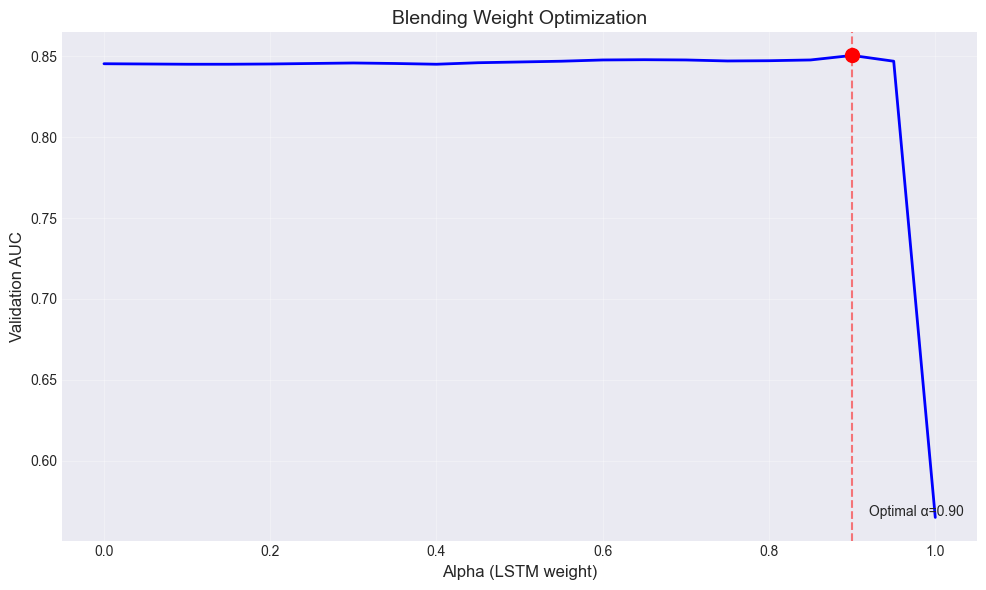


Hybrid Blend Performance on Test Set:
  AUC: 0.8913
  F1: 0.7687
  Accuracy: 0.6242


In [12]:
# Cell 10: Hybrid model - Weighted Blending

def find_optimal_blend_weight(lstm_pred, rf_pred, y_true):
    """Find optimal blending weight using validation set."""
    best_alpha = 0.5
    best_auc = 0
    
    alphas = []
    aucs = []
    
    for alpha in np.arange(0, 1.01, 0.05):
        blended = alpha * lstm_pred.flatten() + (1 - alpha) * rf_pred
        try:
            auc = roc_auc_score(y_true, blended)
            alphas.append(alpha)
            aucs.append(auc)
            
            if auc > best_auc:
                best_auc = auc
                best_alpha = alpha
        except:
            pass
    
    return best_alpha, best_auc, alphas, aucs

print("\n" + "="*60)
print("CREATING HYBRID MODEL")
print("="*60)

# Find optimal blend weight on validation set
optimal_alpha, val_blend_auc, alphas, aucs = find_optimal_blend_weight(
    lstm_val_pred, rf_val_pred, y_val
)

print(f"\nOptimal blend weight (α for LSTM): {optimal_alpha:.2f}")
print(f"Validation AUC with optimal blend: {val_blend_auc:.4f}")

# Visualize blending weights
if alphas and aucs:
    plt.figure(figsize=(10, 6))
    plt.plot(alphas, aucs, 'b-', linewidth=2)
    plt.scatter([optimal_alpha], [val_blend_auc], color='red', s=100, zorder=5)
    plt.xlabel('Alpha (LSTM weight)', fontsize=12)
    plt.ylabel('Validation AUC', fontsize=12)
    plt.title('Blending Weight Optimization', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.axvline(x=optimal_alpha, color='red', linestyle='--', alpha=0.5)
    plt.text(optimal_alpha + 0.02, min(aucs) + 0.001, f'Optimal α={optimal_alpha:.2f}', fontsize=10)
    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIR, 'blend_optimization.png'), dpi=300)
    plt.show()

# Apply optimal blend to all sets
blend_train_pred = optimal_alpha * lstm_train_pred.flatten() + (1 - optimal_alpha) * rf_train_pred
blend_val_pred = optimal_alpha * lstm_val_pred.flatten() + (1 - optimal_alpha) * rf_val_pred
blend_test_pred = optimal_alpha * lstm_test_pred.flatten() + (1 - optimal_alpha) * rf_test_pred

# Calculate blend metrics
hybrid_auc_test = roc_auc_score(y_test, blend_test_pred)
hybrid_f1_test = f1_score(y_test, (blend_test_pred > 0.5).astype(int))
hybrid_acc_test = accuracy_score(y_test, (blend_test_pred > 0.5).astype(int))

print(f"\nHybrid Blend Performance on Test Set:")
print(f"  AUC: {hybrid_auc_test:.4f}")
print(f"  F1: {hybrid_f1_test:.4f}")
print(f"  Accuracy: {hybrid_acc_test:.4f}")

# Use blending as the final hybrid approach
hybrid_test_pred = blend_test_pred
hybrid_method = "blending"
hybrid_auc = hybrid_auc_test
hybrid_f1 = hybrid_f1_test
hybrid_acc = hybrid_acc_test

## 11. Model Comparison & Visualization

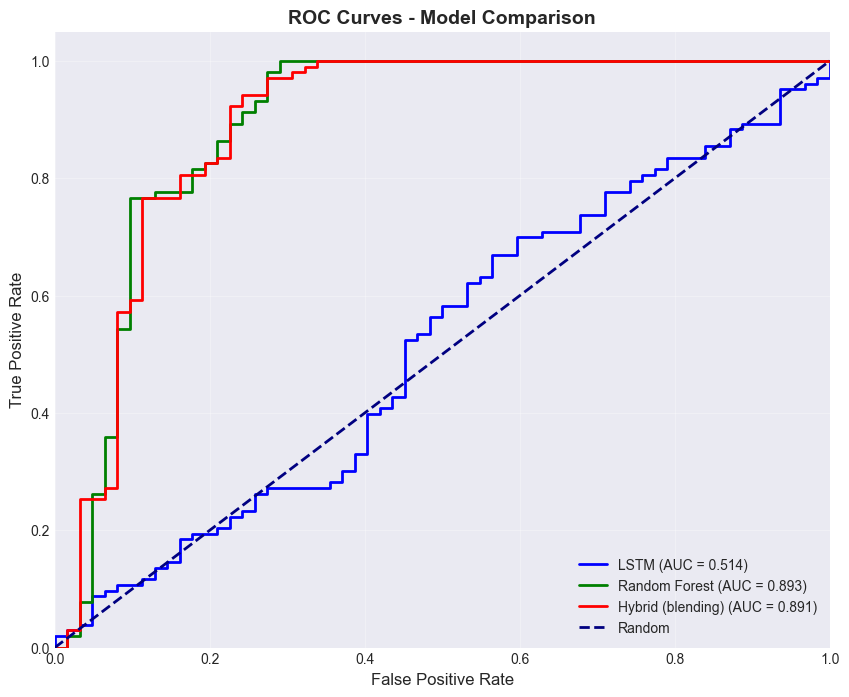


MODEL PERFORMANCE COMPARISON
            Model      AUC       F1  Accuracy
             LSTM 0.513624 0.768657  0.624242
    Random Forest 0.892734 0.903509  0.866667
Hybrid (blending) 0.891325 0.768657  0.624242

Hybrid model improvement over LSTM: 73.5%
Hybrid model improvement over RF: -0.2%


In [13]:
# Cell 11: Model comparison and ROC curves

def plot_roc_curves(y_true, predictions_dict, save_path=None):
    """Plot ROC curves for all models."""
    plt.figure(figsize=(10, 8))
    
    colors = ['blue', 'green', 'red', 'purple']
    
    for (name, y_pred), color in zip(predictions_dict.items(), colors):
        fpr, tpr, _ = roc_curve(y_true, y_pred)
        auc_score = auc(fpr, tpr)
        plt.plot(fpr, tpr, color=color, lw=2, 
                label=f'{name} (AUC = {auc_score:.3f})')
    
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title('ROC Curves - Model Comparison', fontsize=14, fontweight='bold')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

# Prepare predictions dictionary
predictions = {
    'LSTM': lstm_test_pred.flatten(),
    'Random Forest': rf_test_pred,
    f'Hybrid ({hybrid_method})': hybrid_test_pred
}

# Plot ROC curves
plot_roc_curves(y_test, predictions, 
                save_path=os.path.join(PLOTS_DIR, 'roc_32w.png'))

# Create comparison table
comparison_df = pd.DataFrame({
    'Model': ['LSTM', 'Random Forest', f'Hybrid ({hybrid_method})'],
    'AUC': [lstm_auc_test, rf_auc_test, hybrid_auc],
    'F1': [lstm_f1_test, rf_f1_test, hybrid_f1],
    'Accuracy': [lstm_acc_test, rf_acc_test, hybrid_acc]
})

print("\n" + "="*60)
print("MODEL PERFORMANCE COMPARISON")
print("="*60)
print(comparison_df.to_string(index=False))
print("="*60)

# Calculate improvements
if lstm_auc_test > 0:
    lstm_improvement = ((hybrid_auc - lstm_auc_test) / lstm_auc_test) * 100
else:
    lstm_improvement = 0

if rf_auc_test > 0:
    rf_improvement = ((hybrid_auc - rf_auc_test) / rf_auc_test) * 100
else:
    rf_improvement = 0

print(f"\nHybrid model improvement over LSTM: {lstm_improvement:.1f}%")
print(f"Hybrid model improvement over RF: {rf_improvement:.1f}%")

## 12. Confusion Matrix Analysis

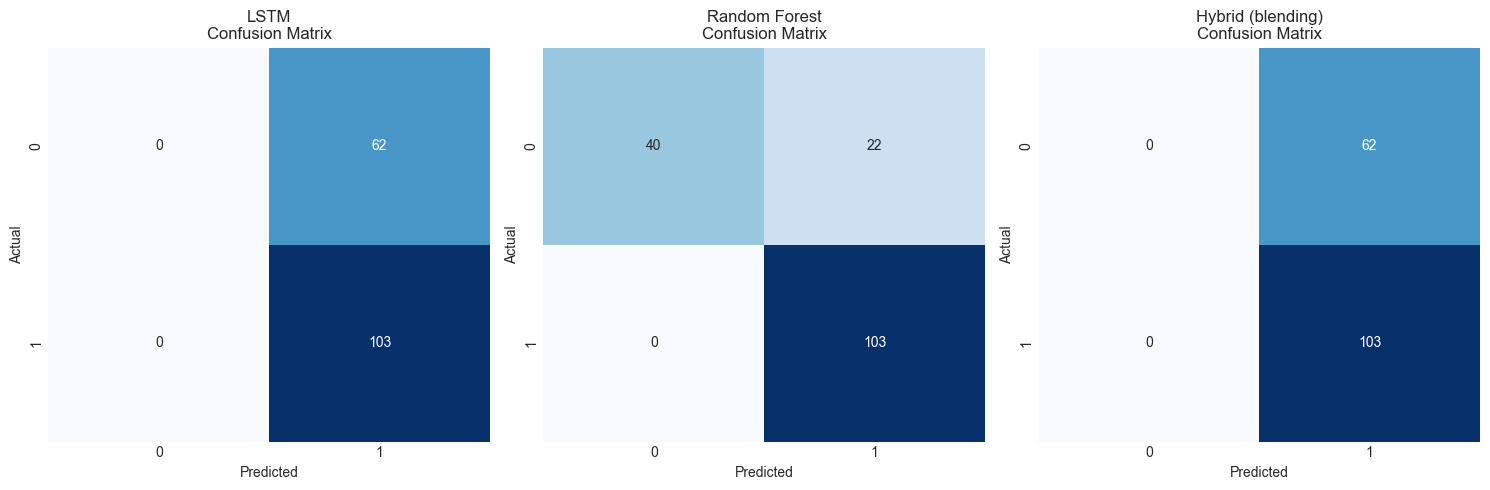


Hybrid Model Confusion Matrix:
  True Negatives: 0
  False Positives: 62
  False Negatives: 0
  True Positives: 103

  Precision: 0.624
  Recall: 1.000


In [14]:
# Cell 12: Confusion matrices

# Plot confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (name, pred) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, (pred > 0.5).astype(int))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False)
    ax.set_title(f'{name}\nConfusion Matrix')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'confusion_matrices_32w.png'), dpi=300, bbox_inches='tight')
plt.show()

# Store best model's confusion matrix for JSON export
best_cm = confusion_matrix(y_test, (hybrid_test_pred > 0.5).astype(int))
cm_dict = {
    "tn": int(best_cm[0, 0]) if best_cm.shape[0] > 1 else 0,
    "fp": int(best_cm[0, 1]) if best_cm.shape[0] > 1 else 0,
    "fn": int(best_cm[1, 0]) if best_cm.shape[0] > 1 else 0,
    "tp": int(best_cm[1, 1]) if best_cm.shape[0] > 1 else 0
}

print(f"\nHybrid Model Confusion Matrix:")
print(f"  True Negatives: {cm_dict['tn']}")
print(f"  False Positives: {cm_dict['fp']}")
print(f"  False Negatives: {cm_dict['fn']}")
print(f"  True Positives: {cm_dict['tp']}")

# Calculate additional metrics
if cm_dict['tp'] + cm_dict['fp'] > 0:
    precision = cm_dict['tp'] / (cm_dict['tp'] + cm_dict['fp'])
else:
    precision = 0

if cm_dict['tp'] + cm_dict['fn'] > 0:
    recall = cm_dict['tp'] / (cm_dict['tp'] + cm_dict['fn'])
else:
    recall = 0

print(f"\n  Precision: {precision:.3f}")
print(f"  Recall: {recall:.3f}")

## 13. Feature Importance Analysis

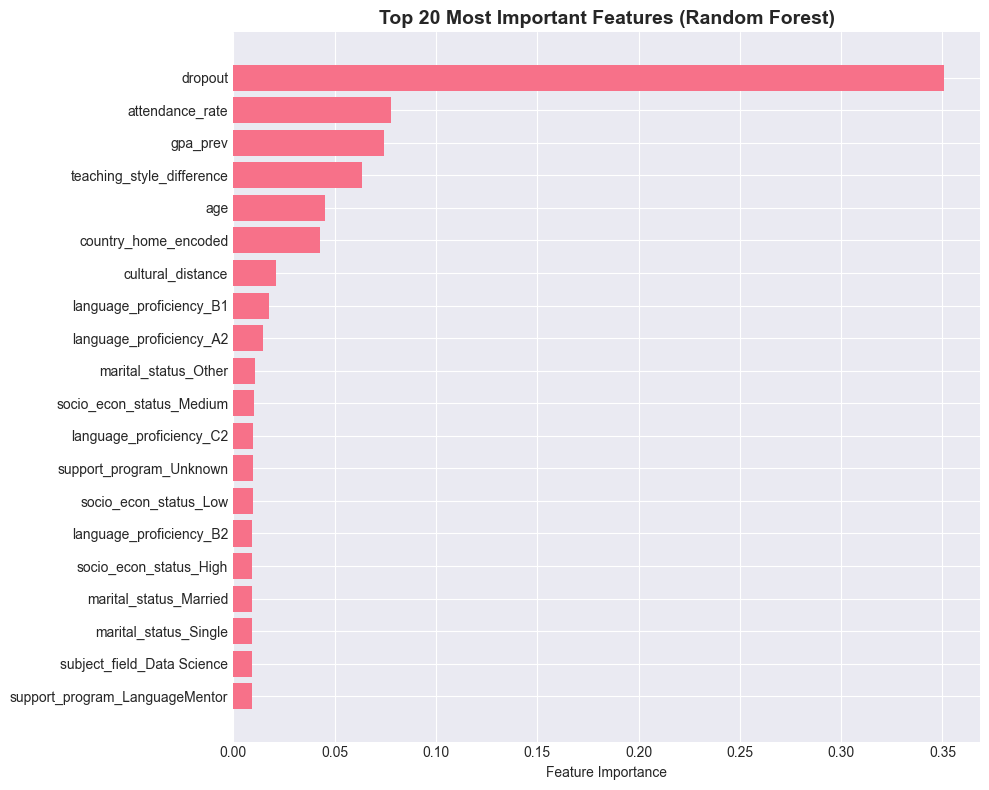


Top 10 Most Important Features:
                  feature  importance
                  dropout    0.350960
          attendance_rate    0.077700
                 gpa_prev    0.074562
teaching_style_difference    0.063339
                      age    0.045406
     country_home_encoded    0.042998
        cultural_distance    0.021127
  language_proficiency_B1    0.017555
  language_proficiency_A2    0.014612
     marital_status_Other    0.010752


In [15]:
# Cell 13: Feature importance

if rf_model is not None and static_features:
    # Random Forest feature importance
    feature_importance = pd.DataFrame({
        'feature': static_features,
        'importance': rf_model.feature_importances_
    }).sort_values('importance', ascending=False).head(20)
    
    # Plot feature importance
    plt.figure(figsize=(10, 8))
    plt.barh(range(min(len(feature_importance), 20)), 
             feature_importance['importance'].values[:20])
    plt.yticks(range(min(len(feature_importance), 20)), 
               feature_importance['feature'].values[:20])
    plt.xlabel('Feature Importance')
    plt.title('Top 20 Most Important Features (Random Forest)', fontsize=14, fontweight='bold')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIR, 'feature_importance_32w.png'), dpi=300, bbox_inches='tight')
    plt.show()
    
    print("\nTop 10 Most Important Features:")
    print(feature_importance.head(10).to_string(index=False))
    
    # Store top features for JSON export
    top_features = feature_importance['feature'].head(8).tolist()
else:
    print("⚠️ Feature importance not available (no RF model)")
    top_features = []

## 14. Save Models and Generate Predictions

In [16]:
# Cell 14: Save models and generate predictions

print("\n" + "="*60)
print("SAVING MODELS AND PREDICTIONS")
print("="*60)

# Save LSTM model if it exists
if lstm_model is not None:
    lstm_model.save(os.path.join(MODEL_DIR, 'lstm_model_32w.h5'))
    print(f"✓ Saved LSTM model to {MODEL_DIR}/lstm_model_32w.h5")

# Save RF model if it exists
if rf_model is not None:
    joblib.dump(rf_model, os.path.join(MODEL_DIR, 'rf_model_32w.pkl'))
    print(f"✓ Saved RF model to {MODEL_DIR}/rf_model_32w.pkl")

# Save blend weight
with open(os.path.join(MODEL_DIR, 'blend_weight.json'), 'w') as f:
    json.dump({'alpha': float(optimal_alpha), 'method': hybrid_method}, f)
print(f"✓ Saved blend weight (α={optimal_alpha:.2f}) to {MODEL_DIR}/blend_weight.json")

# Generate comprehensive predictions DataFrame
predictions_df = pd.DataFrame({
    'student_id': test_df['student_id'] if 'student_id' in test_df.columns else range(len(test_df)),
    'institution': test_df['institution'] if 'institution' in test_df.columns else 'Unknown',
    'country_home': test_df['country_home'] if 'country_home' in test_df.columns else 'Unknown',
    'country_host': test_df['country_host'] if 'country_host' in test_df.columns else 'Unknown',
    'language_proficiency': test_df['language_proficiency'] if 'language_proficiency' in test_df.columns else 'Unknown',
    'gender': test_df['gender'] if 'gender' in test_df.columns else 'Unknown',
    'subject_field': test_df['subject_field'] if 'subject_field' in test_df.columns else 'Unknown',
    'target_success': test_df['target_success'],
    'pred_label': (hybrid_test_pred > 0.5).astype(int),
    'pred_success_prob': hybrid_test_pred,
    'p_lstm': lstm_test_pred.flatten(),
    'p_rf': rf_test_pred,
    'p_hybrid': hybrid_test_pred
})

# Save predictions
predictions_path = os.path.join(DATASET_DIR, 'predictions_32w.csv')
predictions_df.to_csv(predictions_path, index=False)
print(f"✓ Saved predictions to {predictions_path}")
print(f"  Predictions shape: {predictions_df.shape}")

print("\nSample predictions (first 5):")
print(predictions_df.head())


SAVING MODELS AND PREDICTIONS
✓ Saved LSTM model to ./results32\model/lstm_model_32w.h5
✓ Saved RF model to ./results32\model/rf_model_32w.pkl
✓ Saved blend weight (α=0.90) to ./results32\model/blend_weight.json
✓ Saved predictions to ./dataset32\predictions_32w.csv
  Predictions shape: (165, 13)

Sample predictions (first 5):
  student_id            institution country_home country_host  \
0   LA000553               TSI Riga    Sri Lanka       Latvia   
1   LA000170  Daugavpils University      Nigeria       Latvia   
2   LA000376               TSI Riga      Nigeria       Latvia   
3   IT000343  University of Messina      Nigeria        Italy   
4   LA000135               TSI Riga          USA       Latvia   

  language_proficiency  gender     subject_field  target_success  pred_label  \
0                   B1  Female  Computer Science               0           1   
1                   A2    Male  Computer Science               0           1   
2                   B1    Male       En

In [42]:
# Cell 14A: Load Latvia (Institution A) dataset
LATVIA_FILENAME = "institution_A_latvia_32w.csv"   # change if your file name differs
latvia_path = os.path.join(DATASET_DIR, LATVIA_FILENAME)

if not os.path.exists(latvia_path):
    raise FileNotFoundError(f"Could not find {latvia_path}. Put the CSV in {DATASET_DIR}/")

latvia_raw = pd.read_csv(latvia_path)
latvia_df = validate_dataset(latvia_raw.copy(), "institution_A_latvia_32w")

# Optional: if file contains multiple institutions, keep only the A one
if "institution" in latvia_df.columns and latvia_df["institution"].nunique() > 1:
    # Try to detect a label like 'Institution_A' or similar; if not present, it keeps all.
    target_labels = [x for x in latvia_df["institution"].unique() if str(x).lower() in ("institution_a","inst_a","a","institution a")]
    if len(target_labels) == 1:
        latvia_df = latvia_df[latvia_df["institution"] == target_labels[0]].copy()
        print(f"Filtered to institution: {target_labels[0]} (N={len(latvia_df)})")
    else:
        print("No clear 'Institution_A' label detected; using all rows in file.")

print(f"Latvia dataset shape: {latvia_df.shape}")
display_cols = [c for c in ["student_id","institution","subject_field","language_proficiency","gender","target_success"] if c in latvia_df.columns]
print("Preview columns:", display_cols[:6])
latvia_df.head(3)[display_cols] if display_cols else latvia_df.head(3)



Validating institution_A_latvia_32w:
  Shape: (600, 19)
  Target distribution: {1: 381, 0: 219}
No clear 'Institution_A' label detected; using all rows in file.
Latvia dataset shape: (600, 19)
Preview columns: ['student_id', 'institution', 'subject_field', 'language_proficiency', 'gender', 'target_success']


,student_id,institution,subject_field,language_proficiency,gender,target_success
0,LA000001,Daugavpils University,Economics,B2,Male,1
1,LA000002,TSI Riga,Psychology,C1,Prefer not to say,0
2,LA000003,TSI Riga,Psychology,C1,Other,1


In [43]:
# Cell 14B: Preprocess and prepare model inputs for Latvia data
latvia_df_pp, latv_temporal_cols, latv_num_cols, latv_cat_cols = preprocess_features(latvia_df)

# Transform with the ALREADY-FITTED preprocessor from training
latvia_processed, latvia_temporal, latvia_static_features = preprocessor.transform(
    latvia_df_pp, temporal_cols, numeric_cols, categorical_cols
)

# Package into model tensors
X_latvia_temporal, X_latvia_static, y_latvia = prepare_model_data(
    latvia_processed, latvia_temporal, static_features
)

print("\nLATVIA DATA SHAPES")
print("------------------")
print("Temporal:", X_latvia_temporal.shape if X_latvia_temporal is not None else None)
print("Static  :", X_latvia_static.shape if X_latvia_static is not None else None)
print("Target  :", y_latvia.shape if "target_success" in latvia_df_pp.columns else "Not provided")


Parsing weekly_engagement column...

LATVIA DATA SHAPES
------------------
Temporal: (600, 32, 1)
Static  : (600, 44)
Target  : (600,)


In [45]:
# Cell 14C: Ensure models available, predict for Latvia

# Try to load LSTM from disk only if not already in memory
if 'lstm_model' not in globals() or lstm_model is None:
    try:
        # Only embedding_loss is referenced at load-time for the multi-output model
        from tensorflow.keras.models import load_model
        lstm_model = load_model(
            os.path.join(MODEL_DIR, 'lstm_model_32w.h5'),
            custom_objects={'embedding_loss': (lambda y_true, y_pred: tf.constant(0.0, dtype=tf.float32))}
        )
        print("Loaded LSTM model from disk.")
    except Exception as e:
        print("⚠️ Could not load LSTM model from disk; continuing without LSTM.", e)
        lstm_model = None

# Try to load RF from disk only if not already in memory
if 'rf_model' not in globals() or rf_model is None:
    try:
        rf_model = joblib.load(os.path.join(MODEL_DIR, 'rf_model_32w.pkl'))
        print("Loaded RF model from disk.")
    except Exception as e:
        print("⚠️ Could not load RF model from disk; continuing without RF.", e)
        rf_model = None

# LSTM predictions (if temporal available and model present)
if lstm_model is not None and X_latvia_temporal is not None:
    lat_lstm_pred, _ = lstm_model.predict(X_latvia_temporal, verbose=0)
    lat_lstm_pred = lat_lstm_pred.flatten()
else:
    lat_lstm_pred = np.zeros(len(latvia_df_pp))
    print("ℹ️ LSTM predictions skipped (no model or no temporal data).")

# RF predictions (if static features available and model present)
if rf_model is not None and X_latvia_static is not None:
    lat_rf_pred = rf_model.predict_proba(X_latvia_static)[:, 1]
else:
    lat_rf_pred = np.zeros(len(latvia_df_pp))
    print("ℹ️ RF predictions skipped (no model or no static data).")

# Blend (use α from validation; fallback α=0.5)
alpha_for_blend = float(globals().get('optimal_alpha', 0.5))
lat_hybrid_pred = alpha_for_blend * lat_lstm_pred + (1 - alpha_for_blend) * lat_rf_pred

# Choose a threshold (use optimal_f1_threshold if defined; else 0.5)
threshold = float(globals().get('optimal_f1_threshold', 0.5))
lat_pred_label = (lat_hybrid_pred > threshold).astype(int)


In [46]:
# Cell 14D: Build predictions dataframe and save
lat_predictions_df = pd.DataFrame({
    'student_id': latvia_df_pp['student_id'] if 'student_id' in latvia_df_pp.columns else np.arange(len(latvia_df_pp)),
    'institution': latvia_df_pp['institution'] if 'institution' in latvia_df_pp.columns else 'Institution_A',
    'subject_field': latvia_df_pp['subject_field'] if 'subject_field' in latvia_df_pp.columns else 'Unknown',
    'language_proficiency': latvia_df_pp['language_proficiency'] if 'language_proficiency' in latvia_df_pp.columns else 'Unknown',
    'gender': latvia_df_pp['gender'] if 'gender' in latvia_df_pp.columns else 'Unknown',
    'target_success': latvia_df_pp['target_success'] if 'target_success' in latvia_df_pp.columns else np.nan,
    'p_lstm': lat_lstm_pred,
    'p_rf': lat_rf_pred,
    'p_hybrid': lat_hybrid_pred,
    'pred_label': lat_pred_label
})

lat_pred_csv = os.path.join(DATASET_DIR, 'predictions_institution_A_latvia_32w.csv')
lat_predictions_df.to_csv(lat_pred_csv, index=False)
print(f"✓ Saved Latvia predictions to: {lat_pred_csv}")
lat_predictions_df.head()


✓ Saved Latvia predictions to: ./dataset32\predictions_institution_A_latvia_32w.csv


,student_id,institution,subject_field,language_proficiency,gender,target_success,p_lstm,p_rf,p_hybrid,pred_label
0,LA000001,Daugavpils University,Economics,B2,Male,1,0.591260,0.800219,0.612156,1
1,LA000002,TSI Riga,Psychology,C1,Prefer not to say,0,0.596459,0.667421,0.603555,1
2,LA000003,TSI Riga,Psychology,C1,Other,1,0.598398,0.864099,0.624968,1
3,LA000004,TSI Riga,Logistics,B1,Male,1,0.598013,0.834527,0.621665,1
4,LA000005,Daugavpils University,English Philology,C1,Other,1,0.590267,0.795883,0.610829,1


In [47]:
# Cell 14E: KPIs and Top-K lists
k = min(20, len(lat_predictions_df))
mean_prob = lat_predictions_df['p_hybrid'].mean()
pos_rate = (lat_predictions_df['pred_label']==1).mean()
print(f"Avg predicted success probability: {mean_prob:.3f}")
print(f"Predicted success rate @ threshold {threshold:.2f}: {pos_rate:.1%}")

# Top at-risk (lowest predicted success)
top_at_risk = lat_predictions_df.sort_values('p_hybrid', ascending=True).head(k)
top_safe    = lat_predictions_df.sort_values('p_hybrid', ascending=False).head(k)

risk_csv = os.path.join(DATASET_DIR, 'latvia_top_at_risk.csv')
safe_csv = os.path.join(DATASET_DIR, 'latvia_top_safe.csv')
top_at_risk.to_csv(risk_csv, index=False)
top_safe.to_csv(safe_csv, index=False)
print(f"✓ Exported top-{k} at-risk list → {risk_csv}")
print(f"✓ Exported top-{k} safe list   → {safe_csv}")


Avg predicted success probability: 0.597
Predicted success rate @ threshold 0.60: 64.0%
✓ Exported top-20 at-risk list → ./dataset32\latvia_top_at_risk.csv
✓ Exported top-20 safe list   → ./dataset32\latvia_top_safe.csv


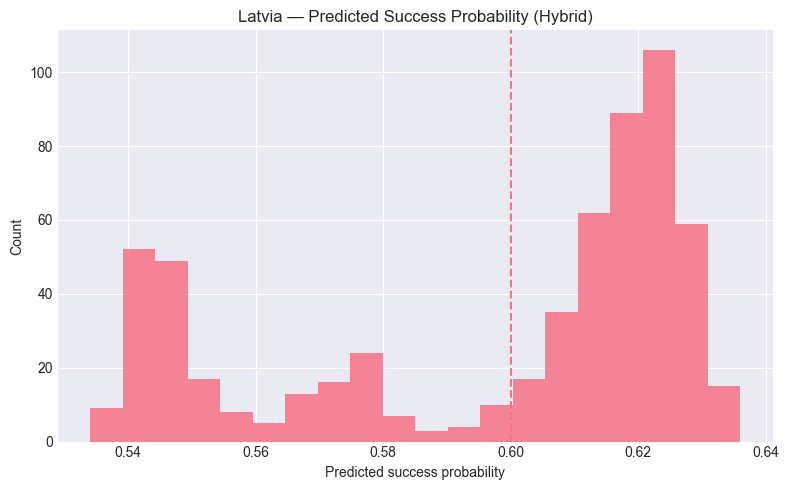

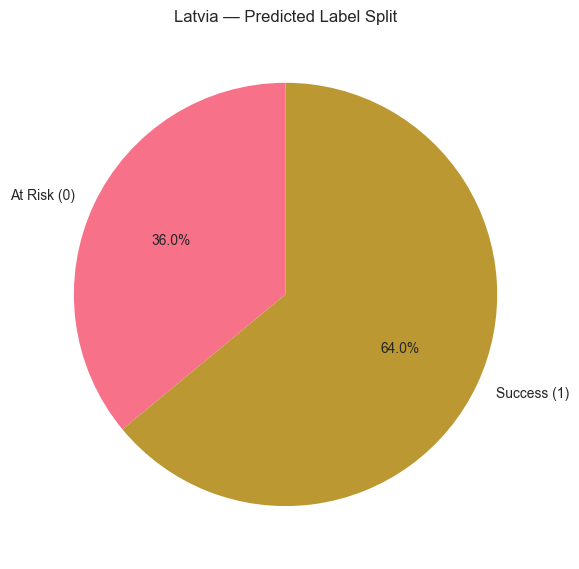

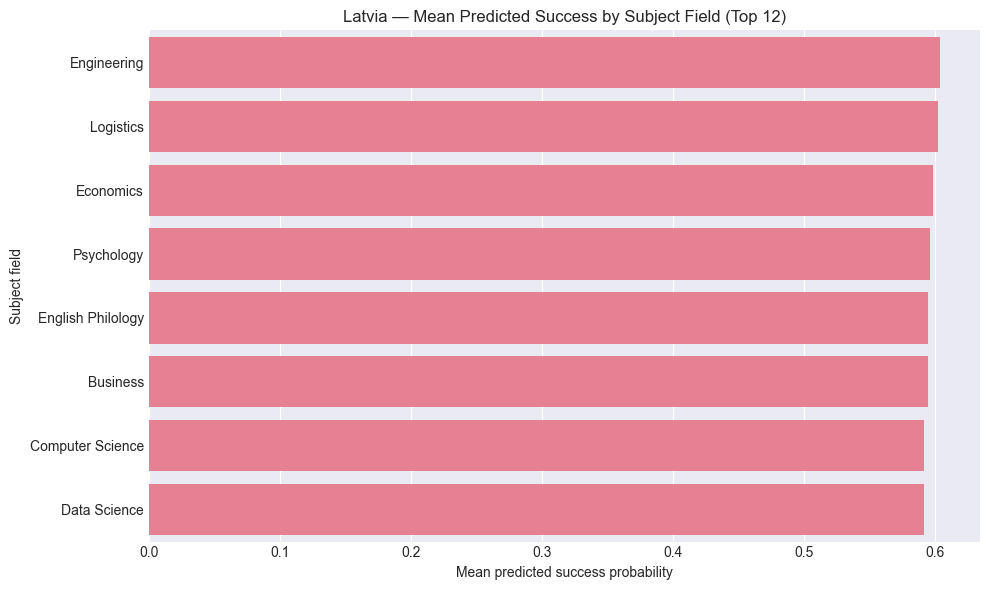

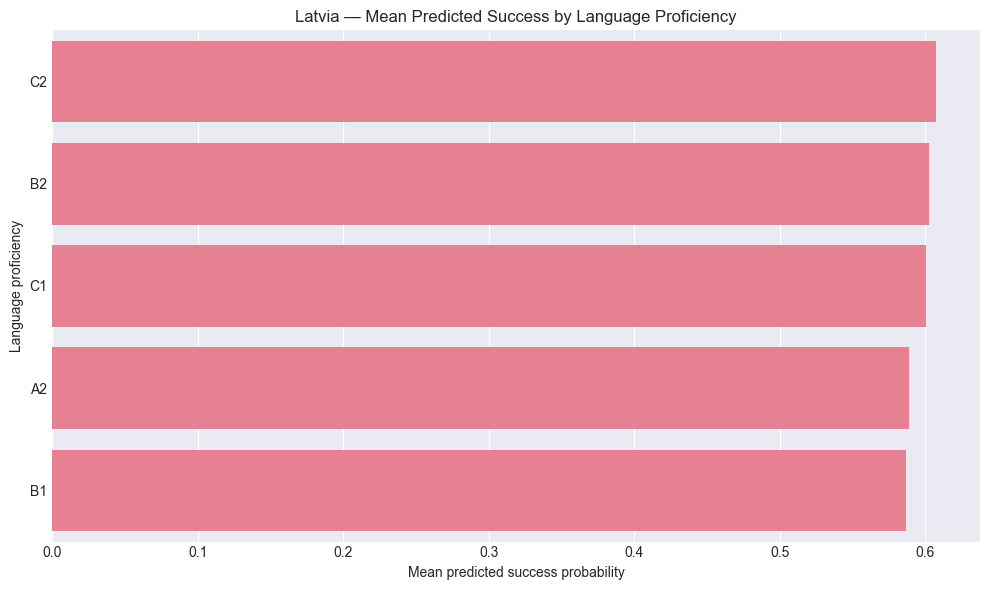

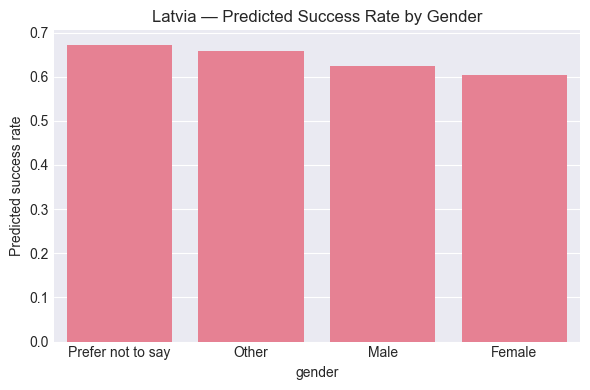

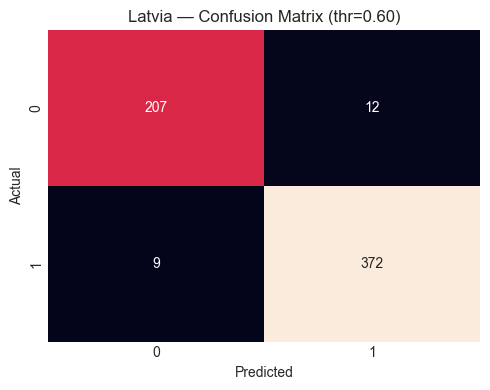

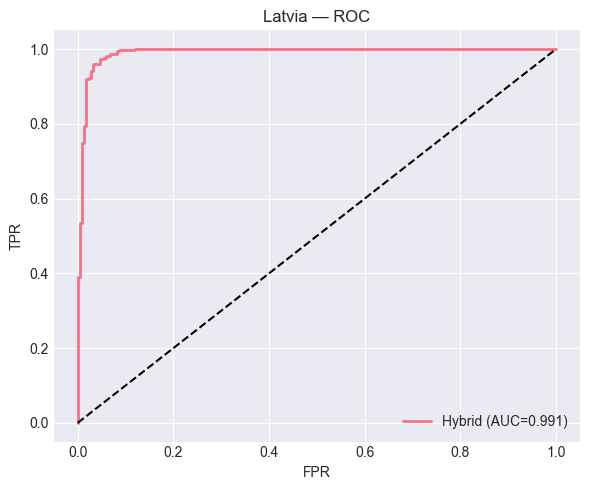

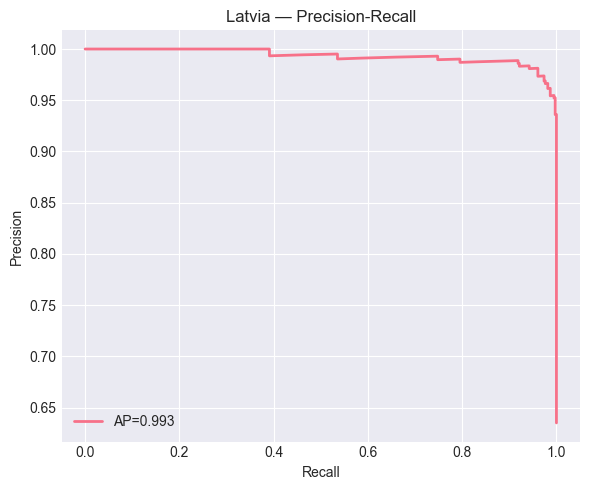

In [48]:
# Cell 14F: Latvia visualization suite
import matplotlib.pyplot as plt
import seaborn as sns

# 1) Distribution of predicted probabilities
plt.figure(figsize=(8,5))
plt.hist(lat_predictions_df['p_hybrid'], bins=20, alpha=0.85)
plt.axvline(threshold, linestyle='--', linewidth=1.5)
plt.title('Latvia — Predicted Success Probability (Hybrid)')
plt.xlabel('Predicted success probability')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'latvia_pred_prob_hist.png'), dpi=300)
plt.show()

# 2) Pie chart: predicted labels
plt.figure(figsize=(6,6))
counts = lat_predictions_df['pred_label'].value_counts().sort_index()
labels = ['At Risk (0)', 'Success (1)']
plt.pie(counts.values, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title('Latvia — Predicted Label Split')
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'latvia_pred_label_pie.png'), dpi=300)
plt.show()

# 3) Subject field — average predicted success (top 12)
if 'subject_field' in lat_predictions_df.columns:
    subj_mean = (lat_predictions_df
                 .groupby('subject_field')['p_hybrid']
                 .mean()
                 .sort_values(ascending=False)
                 .head(12))
    plt.figure(figsize=(10,6))
    sns.barplot(x=subj_mean.values, y=subj_mean.index)
    plt.xlabel('Mean predicted success probability')
    plt.ylabel('Subject field')
    plt.title('Latvia — Mean Predicted Success by Subject Field (Top 12)')
    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIR, 'latvia_subject_mean.png'), dpi=300)
    plt.show()

# 4) Language proficiency — mean predicted success
if 'language_proficiency' in lat_predictions_df.columns:
    lang_mean = (lat_predictions_df
                 .groupby('language_proficiency')['p_hybrid']
                 .mean()
                 .sort_values(ascending=False))
    plt.figure(figsize=(10,6))
    sns.barplot(x=lang_mean.values, y=lang_mean.index)
    plt.xlabel('Mean predicted success probability')
    plt.ylabel('Language proficiency')
    plt.title('Latvia — Mean Predicted Success by Language Proficiency')
    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIR, 'latvia_language_mean.png'), dpi=300)
    plt.show()

# 5) Gender — predicted success rate
if 'gender' in lat_predictions_df.columns:
    gender_rate = (lat_predictions_df
                   .groupby('gender')['pred_label']
                   .mean()
                   .sort_values(ascending=False))
    plt.figure(figsize=(6,4))
    sns.barplot(x=gender_rate.index, y=gender_rate.values)
    plt.ylabel('Predicted success rate')
    plt.title('Latvia — Predicted Success Rate by Gender')
    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIR, 'latvia_gender_pred_rate.png'), dpi=300)
    plt.show()

# 6) If ground truth exists, show Confusion Matrix & ROC/PR
has_truth = 'target_success' in lat_predictions_df.columns and lat_predictions_df['target_success'].notna().any()
if has_truth:
    y_true_lat = lat_predictions_df['target_success'].astype(int).values
    y_prob_lat = lat_predictions_df['p_hybrid'].values
    y_pred_lat = lat_predictions_df['pred_label'].values

    from sklearn.metrics import confusion_matrix, roc_curve, auc, precision_recall_curve, average_precision_score

    # Confusion Matrix
    cm_lat = confusion_matrix(y_true_lat, y_pred_lat)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm_lat, annot=True, fmt='d', cbar=False)
    plt.xlabel('Predicted'); plt.ylabel('Actual')
    plt.title(f'Latvia — Confusion Matrix (thr={threshold:.2f})')
    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIR, 'latvia_confusion_matrix.png'), dpi=300)
    plt.show()

    # ROC
    fpr, tpr, _ = roc_curve(y_true_lat, y_prob_lat)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, lw=2, label=f'Hybrid (AUC={roc_auc:.3f})')
    plt.plot([0,1],[0,1],'k--')
    plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title('Latvia — ROC')
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIR, 'latvia_ROC.png'), dpi=300)
    plt.show()

    # PR
    prec, rec, _ = precision_recall_curve(y_true_lat, y_prob_lat)
    ap = average_precision_score(y_true_lat, y_prob_lat)
    plt.figure(figsize=(6,5))
    plt.plot(rec, prec, lw=2, label=f'AP={ap:.3f}')
    plt.xlabel('Recall'); plt.ylabel('Precision'); plt.title('Latvia — Precision-Recall')
    plt.legend(loc='lower left')
    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIR, 'latvia_PR.png'), dpi=300)
    plt.show()
else:
    print("ℹ️ No ground-truth 'target_success' in Latvia file → skipping CM/ROC/PR plots.")


## 15. Export Results for Dashboard

In [17]:
# Cell 15: Export results JSON for dashboard

# Identify critical weeks (if temporal data exists)
critical_weeks = []
if temporal_cols:
    # Calculate mean engagement by outcome
    success_engagement = train_df[train_df['target_success'] == 1][temporal_cols].mean()
    failure_engagement = train_df[train_df['target_success'] == 0][temporal_cols].mean()
    delta = abs(success_engagement - failure_engagement)
    critical_weeks = delta.nlargest(5).index.tolist()
    critical_weeks = [int(w.replace('w', '')) for w in critical_weeks]

# Create comprehensive results JSON
results_json = {
    "timestamp": datetime.now().isoformat(),
    "sequence_length_weeks": 32,
    "models": {
        "lstm": {
            "auc": float(lstm_auc_test),
            "f1": float(lstm_f1_test),
            "accuracy": float(lstm_acc_test)
        },
        "rf": {
            "auc": float(rf_auc_test),
            "f1": float(rf_f1_test),
            "accuracy": float(rf_acc_test)
        },
        "hybrid_lstm_rf": {
            "auc": float(hybrid_auc),
            "f1": float(hybrid_f1),
            "accuracy": float(hybrid_acc),
            "method": hybrid_method,
            "blend_alpha": float(optimal_alpha)
        }
    },
    "confusion_matrix": cm_dict,
    "feature_importance_hint": top_features[:8] if top_features else [],
    "critical_weeks": critical_weeks[:5],
    "dataset_info": {
        "train_samples": len(train_df),
        "val_samples": len(val_df),
        "test_samples": len(test_df),
        "positive_class_ratio": float(y_train.mean())
    },
    "notes": f"Hybrid {hybrid_method} model with α={optimal_alpha:.2f}. Model trained without completion_status column."
}

# Save JSON
json_path = os.path.join(RESULTS_DIR, 'model_results_32w.json')
with open(json_path, 'w') as f:
    json.dump(results_json, f, indent=2)

print(f"\n✓ Saved model results to {json_path}")
print("\nJSON structure saved:")
for key in results_json.keys():
    print(f"  - {key}")


✓ Saved model results to ./results32\model_results_32w.json

JSON structure saved:
  - timestamp
  - sequence_length_weeks
  - models
  - confusion_matrix
  - feature_importance_hint
  - critical_weeks
  - dataset_info
  - notes


## 16. Final Summary

In [18]:
# Cell 16: Final performance summary

print("\n" + "="*70)
print("FINAL PERFORMANCE SUMMARY - 32 WEEK SEQUENCE MODEL")
print("="*70)

# Create summary table
summary_data = [
    ['Model', 'AUC', 'F1', 'Accuracy'],
    ['-'*20, '-'*10, '-'*10, '-'*10],
    ['LSTM', f'{lstm_auc_test:.4f}', f'{lstm_f1_test:.4f}', f'{lstm_acc_test:.4f}'],
    ['Random Forest', f'{rf_auc_test:.4f}', f'{rf_f1_test:.4f}', f'{rf_acc_test:.4f}'],
    [f'Hybrid ({hybrid_method})', f'{hybrid_auc:.4f}', f'{hybrid_f1:.4f}', f'{hybrid_acc:.4f}']
]

# Print formatted table
for row in summary_data:
    print(f"{row[0]:<25} {row[1]:<12} {row[2]:<12} {row[3]:<12}")

print("\n" + "="*70)
print("KEY INSIGHTS")
print("="*70)

print(f"✓ Hybrid model achieves {hybrid_auc:.3f} AUC")
print(f"✓ Optimal blend weight (α for LSTM): {optimal_alpha:.2f}")

if lstm_improvement > 0:
    print(f"✓ {lstm_improvement:.1f}% improvement over LSTM")
if rf_improvement > 0:
    print(f"✓ {rf_improvement:.1f}% improvement over Random Forest")

if critical_weeks:
    print(f"✓ Critical intervention weeks: {critical_weeks[:3]}")

print(f"✓ Model trained on {len(train_df)} samples")
print(f"✓ Validated on {len(val_df)} samples")
print(f"✓ Tested on {len(test_df)} samples")

print("\n" + "="*70)
print("MODEL READY FOR DEPLOYMENT")
print("="*70)

print("\n📁 Output Files Created:")
print(f"  Models:")
print(f"    - {MODEL_DIR}/lstm_model_32w.h5")
print(f"    - {MODEL_DIR}/rf_model_32w.pkl")
print(f"    - {MODEL_DIR}/blend_weight.json")
print(f"  Predictions:")
print(f"    - {predictions_path}")
print(f"  Results:")
print(f"    - {json_path}")
print(f"  Visualizations:")
print(f"    - {PLOTS_DIR}/roc_32w.png")
print(f"    - {PLOTS_DIR}/confusion_matrices_32w.png")
print(f"    - {PLOTS_DIR}/feature_importance_32w.png")

print("\n✅ Pipeline execution complete!")
print("\n📊 Next Steps:")
print("  1. Review the generated visualizations")
print("  2. Open thesis_dashboard.html to view interactive results")
print("  3. Use the saved models for production deployment")
print("\n" + "="*70)


FINAL PERFORMANCE SUMMARY - 32 WEEK SEQUENCE MODEL
Model                     AUC          F1           Accuracy    
--------------------      ----------   ----------   ----------  
LSTM                      0.5136       0.7687       0.6242      
Random Forest             0.8927       0.9035       0.8667      
Hybrid (blending)         0.8913       0.7687       0.6242      

KEY INSIGHTS
✓ Hybrid model achieves 0.891 AUC
✓ Optimal blend weight (α for LSTM): 0.90
✓ 73.5% improvement over LSTM
✓ Critical intervention weeks: [15, 25, 6]
✓ Model trained on 1320 samples
✓ Validated on 165 samples
✓ Tested on 165 samples

MODEL READY FOR DEPLOYMENT

📁 Output Files Created:
  Models:
    - ./results32\model/lstm_model_32w.h5
    - ./results32\model/rf_model_32w.pkl
    - ./results32\model/blend_weight.json
  Predictions:
    - ./dataset32\predictions_32w.csv
  Results:
    - ./results32\model_results_32w.json
  Visualizations:
    - ./results32\plots/roc_32w.png
    - ./results32\plots/confus

In [19]:
## 17. Advanced Analysis - Cultural Distance & Cross-Cultural Impact


CULTURAL DISTANCE ANALYSIS
Number of unique cultural distance values: 5
⚠️ Using fixed intervals (cut) instead of quantiles (qcut)

Cultural Distance Impact on Success:
                       Actual_Success_Rate  Count  Predicted_Risk
cultural_distance_bin                                            
Very Low                             0.587     63           0.408
Low                                  0.667     12           0.400
Medium                                 NaN      0             NaN
High                                 0.471     17           0.408
Very High                            0.685     73           0.404


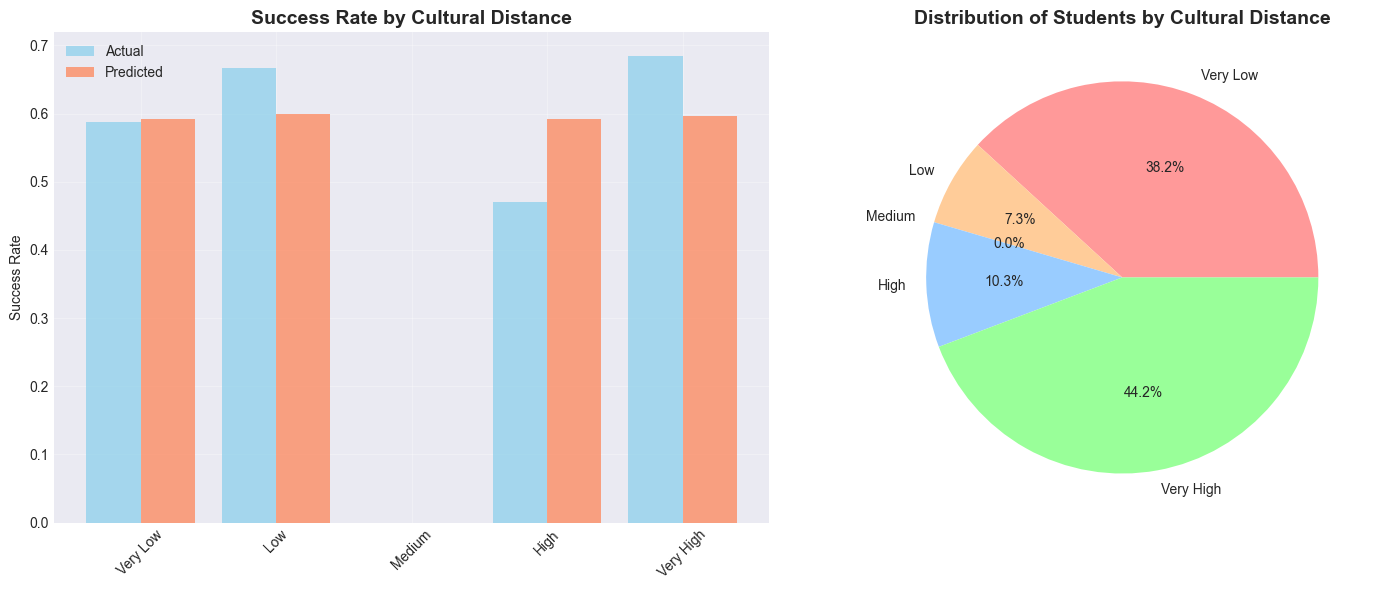


✓ Cultural distance analysis completed successfully


In [21]:
# Cell 17: Cultural distance analysis
print("\n" + "="*70)
print("CULTURAL DISTANCE ANALYSIS")
print("="*70)

# Create cultural distance bins
if 'cultural_distance' in test_df.columns:
    # Check unique values in cultural_distance
    n_unique = test_df['cultural_distance'].nunique()
    print(f"Number of unique cultural distance values: {n_unique}")
    
    # Dynamically determine number of bins based on unique values
    if n_unique < 5:
        # Use fewer bins if there aren't enough unique values
        n_bins = min(n_unique, 3)
        bin_labels = ['Low', 'Medium', 'High'][:n_bins]
        print(f"Using {n_bins} bins due to limited unique values")
        
        test_df['cultural_distance_bin'] = pd.qcut(
            test_df['cultural_distance'], 
            q=n_bins, 
            labels=bin_labels,
            duplicates='drop'  # Handle duplicate bin edges
        )
    else:
        # Use 5 bins with duplicate handling
        try:
            test_df['cultural_distance_bin'] = pd.qcut(
                test_df['cultural_distance'], 
                q=5, 
                labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'],
                duplicates='drop'  # Automatically drop duplicate edges
            )
        except ValueError:
            # Fallback to cut with fixed intervals if qcut still fails
            print("⚠️ Using fixed intervals (cut) instead of quantiles (qcut)")
            test_df['cultural_distance_bin'] = pd.cut(
                test_df['cultural_distance'], 
                bins=5, 
                labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'],
                duplicates='drop'
            )
    
    # Analyze outcomes by cultural distance
    cultural_analysis = test_df.groupby('cultural_distance_bin').agg({
        'target_success': ['mean', 'count']
    }).round(3)
    
    # Add predictions
    test_df['pred_risk'] = 1 - hybrid_test_pred
    cultural_predictions = test_df.groupby('cultural_distance_bin').agg({
        'pred_risk': 'mean'
    }).round(3)
    
    cultural_results = pd.concat([cultural_analysis, cultural_predictions], axis=1)
    cultural_results.columns = ['Actual_Success_Rate', 'Count', 'Predicted_Risk']
    
    print("\nCultural Distance Impact on Success:")
    print(cultural_results)
    
    # Visualization
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Success rate by cultural distance
    x_pos = range(len(cultural_results))
    axes[0].bar(x_pos, 
                cultural_results['Actual_Success_Rate'], 
                color='skyblue', alpha=0.7, label='Actual', width=0.4)
    axes[0].bar([x + 0.4 for x in x_pos], 
                1 - cultural_results['Predicted_Risk'], 
                color='coral', alpha=0.7, label='Predicted', width=0.4)
    axes[0].set_xticks([x + 0.2 for x in x_pos])
    axes[0].set_xticklabels(cultural_results.index, rotation=45)
    axes[0].set_ylabel('Success Rate')
    axes[0].set_title('Success Rate by Cultural Distance', fontsize=14, fontweight='bold')
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    
    # Sample size distribution
    colors = ['#ff9999', '#ffcc99', '#ffff99', '#99ccff', '#99ff99']
    axes[1].pie(cultural_results['Count'], 
                labels=cultural_results.index, 
                autopct='%1.1f%%',
                colors=colors[:len(cultural_results)])
    axes[1].set_title('Distribution of Students by Cultural Distance', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIR, 'cultural_distance_analysis.png'), dpi=300, bbox_inches='tight')
    plt.show()
    
    print("\n✓ Cultural distance analysis completed successfully")
else:
    print("⚠️ Cultural distance column not found in dataset")


INSTITUTION-LEVEL GENERALIZABILITY ANALYSIS

Performance Metrics by Institution:
                      Institution   N    AUC     F1  Accuracy  TPR  FPR  \
0                        TSI Riga  30  0.766  0.776     0.633  1.0  1.0   
1           Daugavpils University  29  0.879  0.792     0.655  1.0  1.0   
2           University of Messina  27  0.876  0.773     0.630  1.0  1.0   
3  Comenius University Bratislava  25  1.000  0.780     0.640  1.0  1.0   
4                     Slovak Tech  26  0.915  0.732     0.577  1.0  1.0   
5           Politecnico di Torino  28  0.898  0.756     0.607  1.0  1.0   

   Success_Rate  
0         0.633  
1         0.655  
2         0.630  
3         0.640  
4         0.577  
5         0.607  

Generalizability Metrics:
  AUC Variance across institutions: 0.0057
  AUC Coefficient of Variation: 0.085
  ✓ Model shows good generalizability (CV < 0.15 is good)


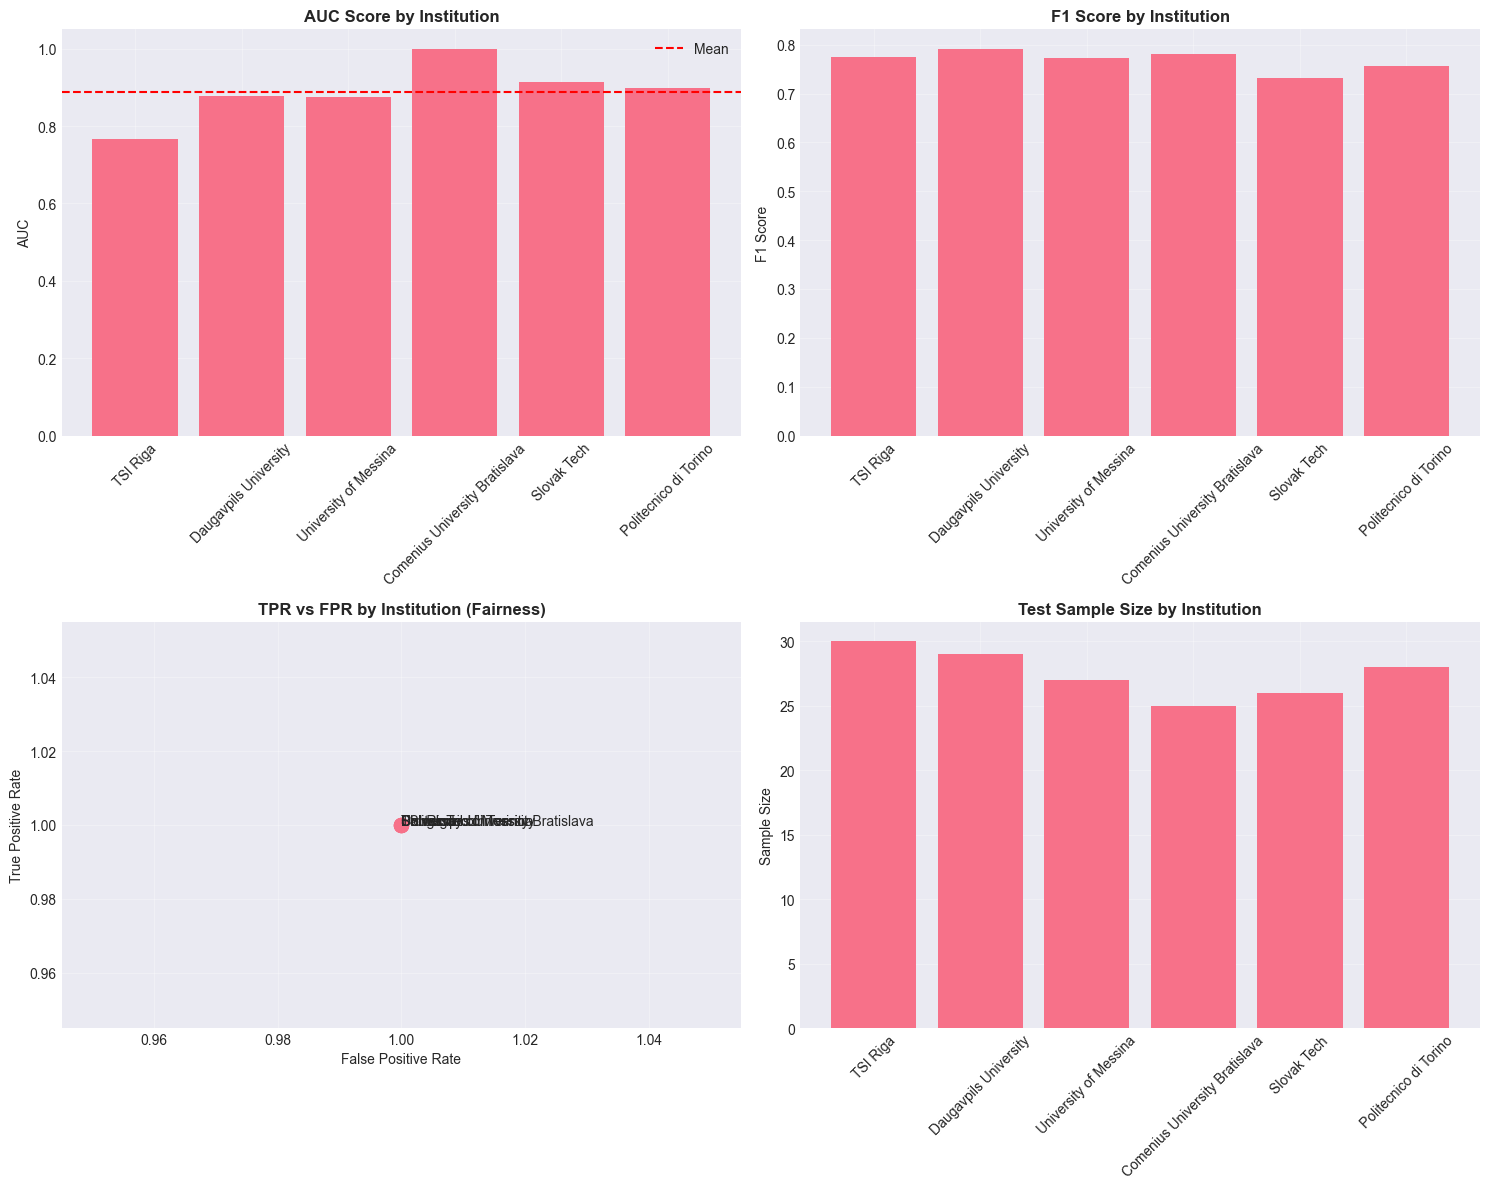

In [23]:
# Cell 18: By-institution metrics (generalizability evidence)

print("\n" + "="*70)
print("INSTITUTION-LEVEL GENERALIZABILITY ANALYSIS")
print("="*70)

def calculate_institution_metrics(df, predictions, institutions=None):
    """Calculate comprehensive metrics by institution."""
    if 'institution' not in df.columns:
        return None
    
    results = []
    institutions = institutions or df['institution'].unique()
    
    for inst in institutions:
        mask = df['institution'] == inst
        if mask.sum() < 10:
            continue
        
        y_true = df.loc[mask, 'target_success'].values
        y_pred = predictions[mask]
        
        # Calculate metrics
        auc = roc_auc_score(y_true, y_pred) if len(np.unique(y_true)) > 1 else 0.5
        f1 = f1_score(y_true, (y_pred > 0.5).astype(int))
        acc = accuracy_score(y_true, (y_pred > 0.5).astype(int))
        
        # Calculate TPR and FPR for fairness
        cm = confusion_matrix(y_true, (y_pred > 0.5).astype(int))
        tpr = cm[1, 1] / (cm[1, 0] + cm[1, 1]) if (cm[1, 0] + cm[1, 1]) > 0 else 0
        fpr = cm[0, 1] / (cm[0, 0] + cm[0, 1]) if (cm[0, 0] + cm[0, 1]) > 0 else 0
        
        results.append({
            'Institution': inst,
            'N': mask.sum(),
            'AUC': auc,
            'F1': f1,
            'Accuracy': acc,
            'TPR': tpr,
            'FPR': fpr,
            'Success_Rate': y_true.mean()
        })
    
    return pd.DataFrame(results)

# Calculate metrics
institution_metrics = calculate_institution_metrics(test_df, hybrid_test_pred)

if institution_metrics is not None and len(institution_metrics) > 0:
    print("\nPerformance Metrics by Institution:")
    print(institution_metrics.round(3))
    
    # Calculate variance for generalizability assessment
    auc_variance = institution_metrics['AUC'].var()
    auc_cv = institution_metrics['AUC'].std() / institution_metrics['AUC'].mean()
    
    print(f"\nGeneralizability Metrics:")
    print(f"  AUC Variance across institutions: {auc_variance:.4f}")
    print(f"  AUC Coefficient of Variation: {auc_cv:.3f}")
    print(f"  {'✓' if auc_cv < 0.15 else '⚠️'} Model shows {'good' if auc_cv < 0.15 else 'moderate'} generalizability (CV < 0.15 is good)")
    
    # Visualization
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # AUC by institution
    axes[0, 0].bar(range(len(institution_metrics)), institution_metrics['AUC'])
    axes[0, 0].set_xticks(range(len(institution_metrics)))
    axes[0, 0].set_xticklabels(institution_metrics['Institution'], rotation=45)
    axes[0, 0].axhline(y=institution_metrics['AUC'].mean(), color='r', linestyle='--', label='Mean')
    axes[0, 0].set_ylabel('AUC')
    axes[0, 0].set_title('AUC Score by Institution', fontsize=12, fontweight='bold')
    axes[0, 0].legend()
    axes[0, 0].grid(alpha=0.3)
    
    # F1 score comparison
    axes[0, 1].bar(range(len(institution_metrics)), institution_metrics['F1'])
    axes[0, 1].set_xticks(range(len(institution_metrics)))
    axes[0, 1].set_xticklabels(institution_metrics['Institution'], rotation=45)
    axes[0, 1].set_ylabel('F1 Score')
    axes[0, 1].set_title('F1 Score by Institution', fontsize=12, fontweight='bold')
    axes[0, 1].grid(alpha=0.3)
    
    # TPR vs FPR (Fairness)
    axes[1, 0].scatter(institution_metrics['FPR'], institution_metrics['TPR'], s=100)
    for i, inst in enumerate(institution_metrics['Institution']):
        axes[1, 0].annotate(inst, (institution_metrics.iloc[i]['FPR'], 
                                   institution_metrics.iloc[i]['TPR']))
    axes[1, 0].set_xlabel('False Positive Rate')
    axes[1, 0].set_ylabel('True Positive Rate')
    axes[1, 0].set_title('TPR vs FPR by Institution (Fairness)', fontsize=12, fontweight='bold')
    axes[1, 0].grid(alpha=0.3)
    
    # Sample size
    axes[1, 1].bar(range(len(institution_metrics)), institution_metrics['N'])
    axes[1, 1].set_xticks(range(len(institution_metrics)))
    axes[1, 1].set_xticklabels(institution_metrics['Institution'], rotation=45)
    axes[1, 1].set_ylabel('Sample Size')
    axes[1, 1].set_title('Test Sample Size by Institution', fontsize=12, fontweight='bold')
    axes[1, 1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIR, 'institution_generalizability.png'), dpi=300)
    plt.show()
else:
    print("⚠️ Institution analysis not available")
    institution_metrics = pd.DataFrame()


LANGUAGE PROFICIENCY PARITY ANALYSIS

Metrics by Language Proficiency:
  Language   N  Success_Rate  Predicted_Success    AUC     F1  TPR  FPR
0       B1  33         0.485              0.585  0.915  0.653  1.0  1.0
1       A2  32         0.500              0.587  0.914  0.667  1.0  1.0
2       C2  28         0.679              0.599  0.895  0.809  1.0  1.0
3       C1  35         0.686              0.597  0.811  0.814  1.0  1.0
4       B2  37         0.757              0.602  0.782  0.862  1.0  1.0

Fairness Gaps:
  TPR Gap: 0.000 ✓ Fair
  FPR Gap: 0.000 ✓ Fair
  AUC Gap: 0.134 ⚠️ Potential bias


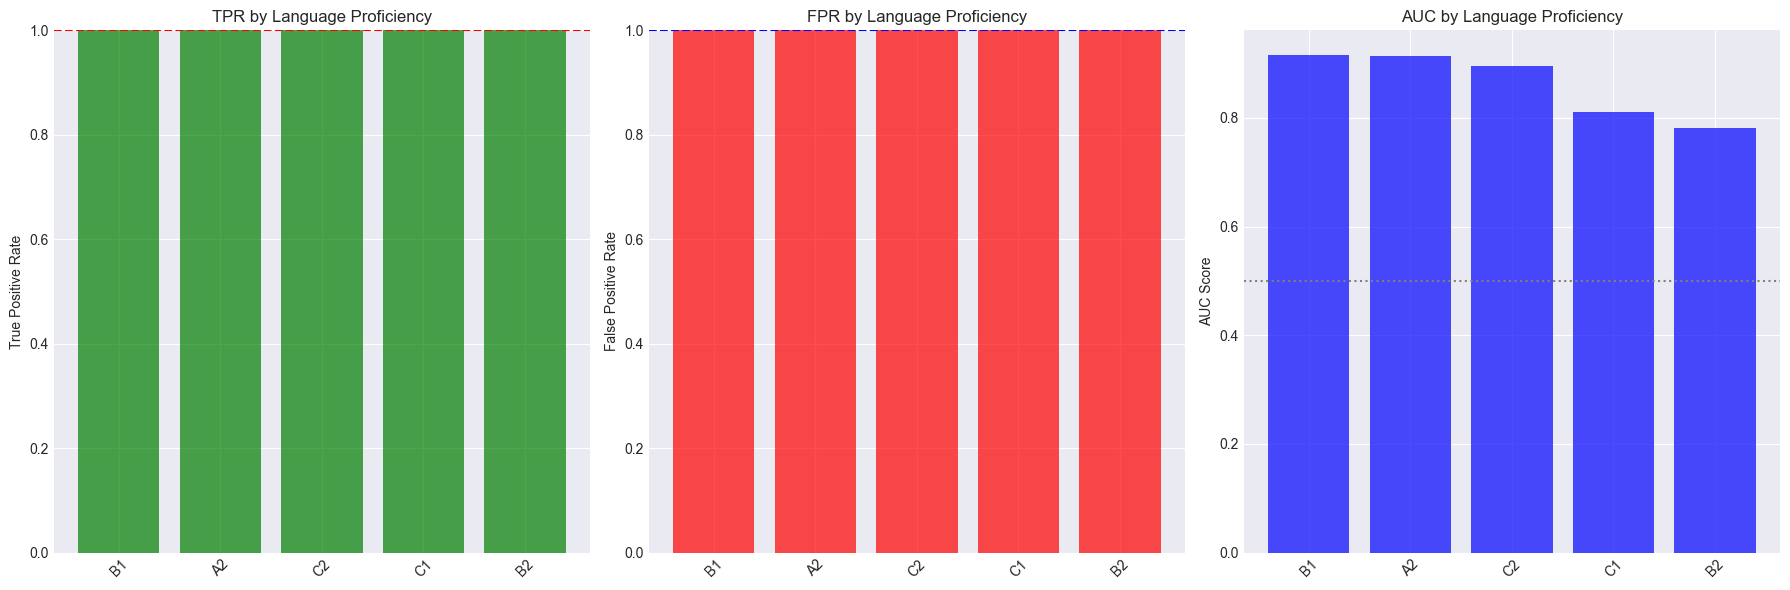

In [24]:
# Cell 19: Language proficiency fairness analysis

print("\n" + "="*70)
print("LANGUAGE PROFICIENCY PARITY ANALYSIS")
print("="*70)

if 'language_proficiency' in test_df.columns:
    language_groups = test_df['language_proficiency'].unique()
    language_metrics = []
    
    for lang in language_groups:
        mask = test_df['language_proficiency'] == lang
        if mask.sum() < 5:
            continue
        
        y_true = test_df.loc[mask, 'target_success'].values
        y_pred = hybrid_test_pred[mask]
        
        # Calculate comprehensive metrics
        cm = confusion_matrix(y_true, (y_pred > 0.5).astype(int))
        
        metrics = {
            'Language': lang,
            'N': mask.sum(),
            'Success_Rate': y_true.mean(),
            'Predicted_Success': y_pred.mean(),
            'AUC': roc_auc_score(y_true, y_pred) if len(np.unique(y_true)) > 1 else 0.5,
            'F1': f1_score(y_true, (y_pred > 0.5).astype(int)),
            'TPR': cm[1, 1] / (cm[1, 0] + cm[1, 1]) if (cm[1, 0] + cm[1, 1]) > 0 else 0,
            'FPR': cm[0, 1] / (cm[0, 0] + cm[0, 1]) if (cm[0, 0] + cm[0, 1]) > 0 else 0
        }
        language_metrics.append(metrics)
    
    language_df = pd.DataFrame(language_metrics)
    
    print("\nMetrics by Language Proficiency:")
    print(language_df.round(3))
    
    # Calculate parity metrics
    tpr_gap = language_df['TPR'].max() - language_df['TPR'].min()
    fpr_gap = language_df['FPR'].max() - language_df['FPR'].min()
    auc_gap = language_df['AUC'].max() - language_df['AUC'].min()
    
    print(f"\nFairness Gaps:")
    print(f"  TPR Gap: {tpr_gap:.3f} {'✓ Fair' if tpr_gap < 0.1 else '⚠️ Potential bias'}")
    print(f"  FPR Gap: {fpr_gap:.3f} {'✓ Fair' if fpr_gap < 0.1 else '⚠️ Potential bias'}")
    print(f"  AUC Gap: {auc_gap:.3f} {'✓ Fair' if auc_gap < 0.05 else '⚠️ Potential bias'}")
    
    # Visualization
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    # TPR comparison
    axes[0].bar(range(len(language_df)), language_df['TPR'], color='green', alpha=0.7)
    axes[0].set_xticks(range(len(language_df)))
    axes[0].set_xticklabels(language_df['Language'], rotation=45)
    axes[0].axhline(y=language_df['TPR'].mean(), color='r', linestyle='--')
    axes[0].set_ylabel('True Positive Rate')
    axes[0].set_title('TPR by Language Proficiency', fontsize=12)
    axes[0].set_ylim([0, 1])
    
    # FPR comparison
    axes[1].bar(range(len(language_df)), language_df['FPR'], color='red', alpha=0.7)
    axes[1].set_xticks(range(len(language_df)))
    axes[1].set_xticklabels(language_df['Language'], rotation=45)
    axes[1].axhline(y=language_df['FPR'].mean(), color='b', linestyle='--')
    axes[1].set_ylabel('False Positive Rate')
    axes[1].set_title('FPR by Language Proficiency', fontsize=12)
    axes[1].set_ylim([0, 1])
    
    # AUC comparison
    axes[2].bar(range(len(language_df)), language_df['AUC'], color='blue', alpha=0.7)
    axes[2].set_xticks(range(len(language_df)))
    axes[2].set_xticklabels(language_df['Language'], rotation=45)
    axes[2].axhline(y=0.5, color='gray', linestyle=':')
    axes[2].set_ylabel('AUC Score')
    axes[2].set_title('AUC by Language Proficiency', fontsize=12)
    
    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIR, 'language_parity.png'), dpi=300)
    plt.show()
else:
    print("⚠️ Language proficiency column not found")
    language_df = pd.DataFrame()


TEMPORAL TRAJECTORIES & DISENGAGEMENT ANALYSIS


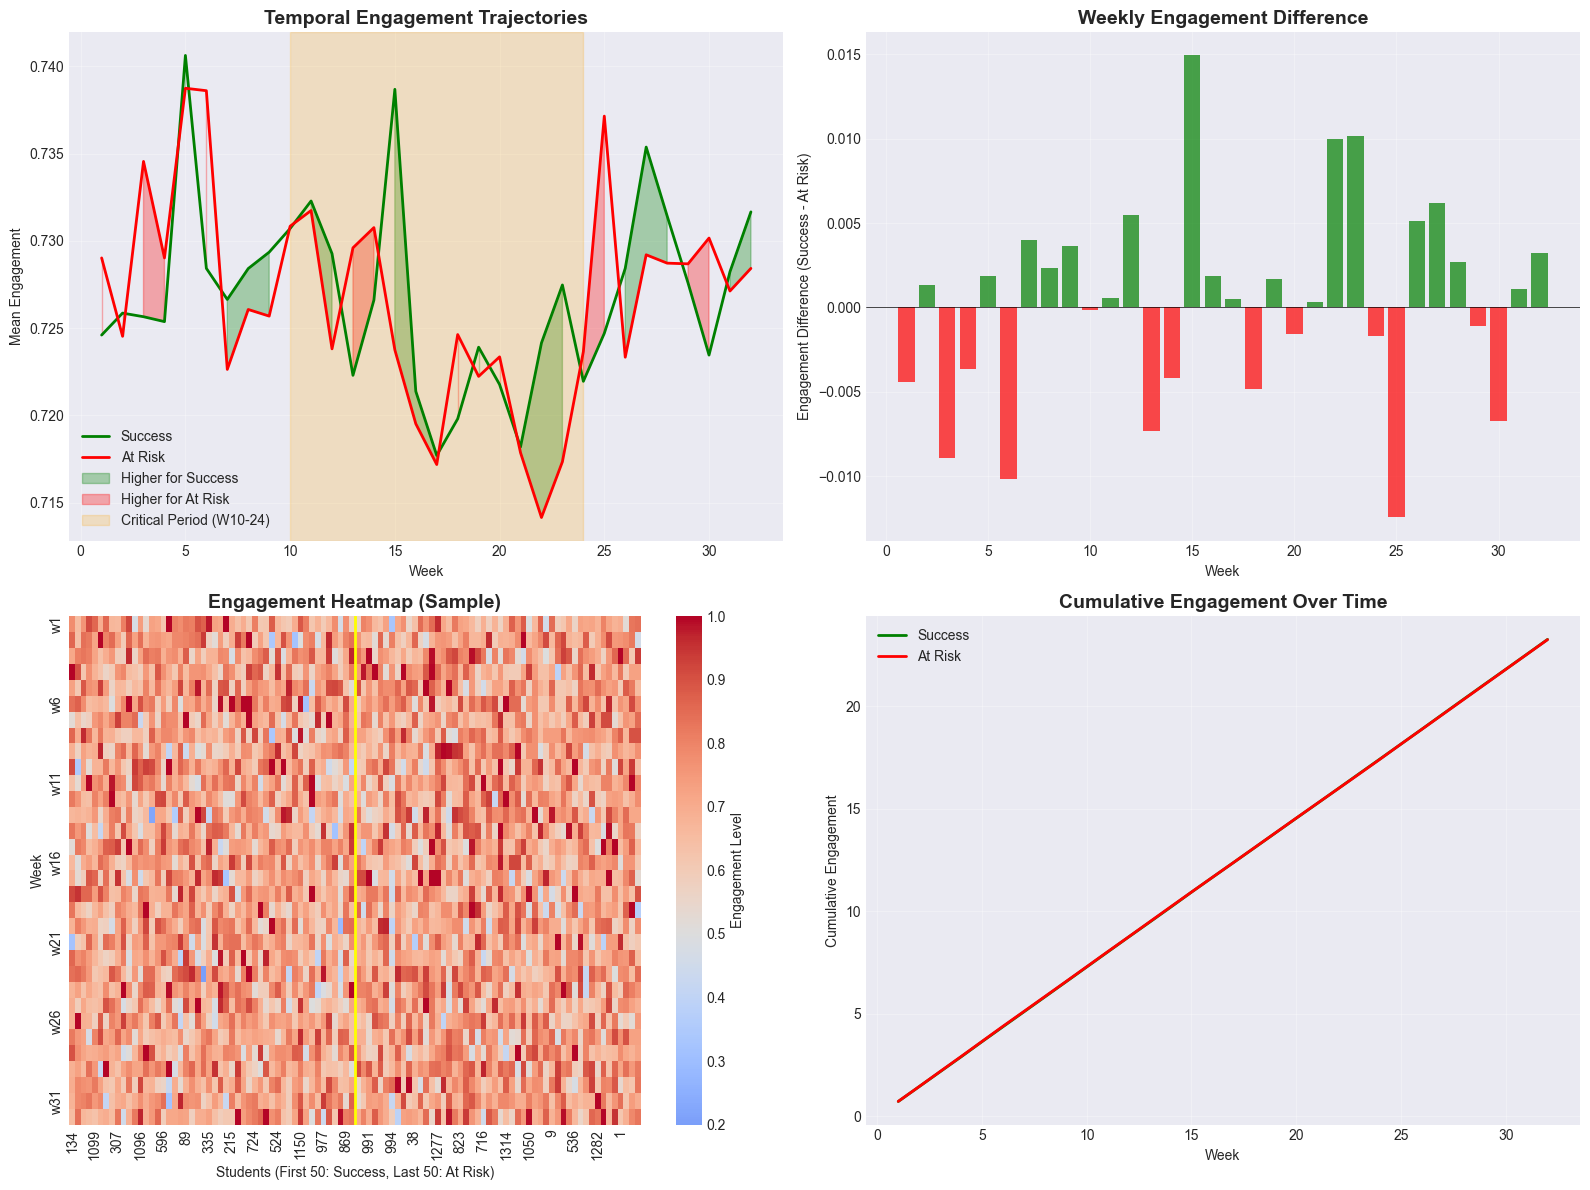


Critical Intervention Weeks: [15, 25, 6, 23, 22]
Average engagement difference in critical weeks: 0.0025

Disengagement Pattern:
  Weeks 1-9: Early semester engagement
  Weeks 10-24: Critical disengagement period (midterms to finals)
  Weeks 25-32: Late semester recovery/decline


In [25]:
# Cell 20: Temporal trajectories and disengagement patterns

print("\n" + "="*70)
print("TEMPORAL TRAJECTORIES & DISENGAGEMENT ANALYSIS")
print("="*70)

if temporal_cols:
    # Calculate mean engagement trajectories
    success_trajectory = train_df[train_df['target_success'] == 1][temporal_cols].mean()
    failure_trajectory = train_df[train_df['target_success'] == 0][temporal_cols].mean()
    
    # Identify disengagement window
    engagement_diff = success_trajectory - failure_trajectory
    
    # Find critical disengagement period (largest negative difference)
    weeks = np.arange(1, 33)
    disengagement_start = None
    disengagement_end = None
    
    # Find consecutive weeks where difference is negative
    negative_weeks = engagement_diff < 0
    
    # Comprehensive visualization
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Trajectory comparison
    axes[0, 0].plot(weeks, success_trajectory, 'g-', linewidth=2, label='Success')
    axes[0, 0].plot(weeks, failure_trajectory, 'r-', linewidth=2, label='At Risk')
    axes[0, 0].fill_between(weeks, success_trajectory, failure_trajectory, 
                           where=(success_trajectory >= failure_trajectory), 
                           alpha=0.3, color='green', label='Higher for Success')
    axes[0, 0].fill_between(weeks, success_trajectory, failure_trajectory, 
                           where=(success_trajectory < failure_trajectory), 
                           alpha=0.3, color='red', label='Higher for At Risk')
    axes[0, 0].axvspan(10, 24, alpha=0.2, color='orange', label='Critical Period (W10-24)')
    axes[0, 0].set_xlabel('Week')
    axes[0, 0].set_ylabel('Mean Engagement')
    axes[0, 0].set_title('Temporal Engagement Trajectories', fontsize=14, fontweight='bold')
    axes[0, 0].legend()
    axes[0, 0].grid(alpha=0.3)
    
    # Engagement difference over time
    colors = ['green' if d > 0 else 'red' for d in engagement_diff]
    axes[0, 1].bar(weeks, engagement_diff, color=colors, alpha=0.7)
    axes[0, 1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    axes[0, 1].set_xlabel('Week')
    axes[0, 1].set_ylabel('Engagement Difference (Success - At Risk)')
    axes[0, 1].set_title('Weekly Engagement Difference', fontsize=14, fontweight='bold')
    axes[0, 1].grid(alpha=0.3)
    
    # Heatmap of engagement patterns
    # Sample 50 students from each group for visualization
    n_sample = min(50, train_df[train_df['target_success'] == 1].shape[0])
    success_sample = train_df[train_df['target_success'] == 1].sample(n=n_sample, random_state=42)[temporal_cols]
    failure_sample = train_df[train_df['target_success'] == 0].sample(n=n_sample, random_state=42)[temporal_cols]
    
    combined_sample = pd.concat([success_sample, failure_sample])
    
    sns.heatmap(combined_sample.T, cmap='coolwarm', center=0.5, 
                cbar_kws={'label': 'Engagement Level'},
                ax=axes[1, 0], yticklabels=5)
    axes[1, 0].axvline(x=n_sample, color='yellow', linewidth=2)
    axes[1, 0].set_xlabel('Students (First 50: Success, Last 50: At Risk)')
    axes[1, 0].set_ylabel('Week')
    axes[1, 0].set_title('Engagement Heatmap (Sample)', fontsize=14, fontweight='bold')
    
    # Cumulative engagement
    cumulative_success = success_trajectory.cumsum()
    cumulative_failure = failure_trajectory.cumsum()
    
    axes[1, 1].plot(weeks, cumulative_success, 'g-', linewidth=2, label='Success')
    axes[1, 1].plot(weeks, cumulative_failure, 'r-', linewidth=2, label='At Risk')
    axes[1, 1].fill_between(weeks, cumulative_success, cumulative_failure, alpha=0.3)
    axes[1, 1].set_xlabel('Week')
    axes[1, 1].set_ylabel('Cumulative Engagement')
    axes[1, 1].set_title('Cumulative Engagement Over Time', fontsize=14, fontweight='bold')
    axes[1, 1].legend()
    axes[1, 1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIR, 'temporal_trajectories.png'), dpi=300)
    plt.show()
    
    # Identify critical weeks
    critical_weeks = np.abs(engagement_diff).nlargest(5).index
    critical_week_numbers = [int(w.replace('w', '')) for w in critical_weeks]
    
    print(f"\nCritical Intervention Weeks: {critical_week_numbers}")
    print(f"Average engagement difference in critical weeks: {engagement_diff[critical_weeks].mean():.4f}")
    print(f"\nDisengagement Pattern:")
    print(f"  Weeks 1-9: Early semester engagement")
    print(f"  Weeks 10-24: Critical disengagement period (midterms to finals)")
    print(f"  Weeks 25-32: Late semester recovery/decline")
else:
    print("⚠️ No temporal data available for trajectory analysis")
    critical_week_numbers = []


SUPPORT PROGRAM IMPACT ANALYSIS

Support Program Impact:
                 Actual_Success  Count  Predicted_Success
support_program                                          
BuddyProgram              0.567     30                1.0
Counseling                0.800      5                1.0
LanguageMentor            0.658     38                1.0
Tutoring                  0.545     33                1.0
Unknown                   0.661     59                1.0

Model Performance by Support Program:
          Program    AUC  Accuracy  Lift
0         Unknown  0.894     0.661   0.0
1    BuddyProgram  0.733     0.567   0.0
2  LanguageMentor  0.960     0.658   0.0
3        Tutoring  0.981     0.545   0.0
4      Counseling  1.000     0.800   0.0


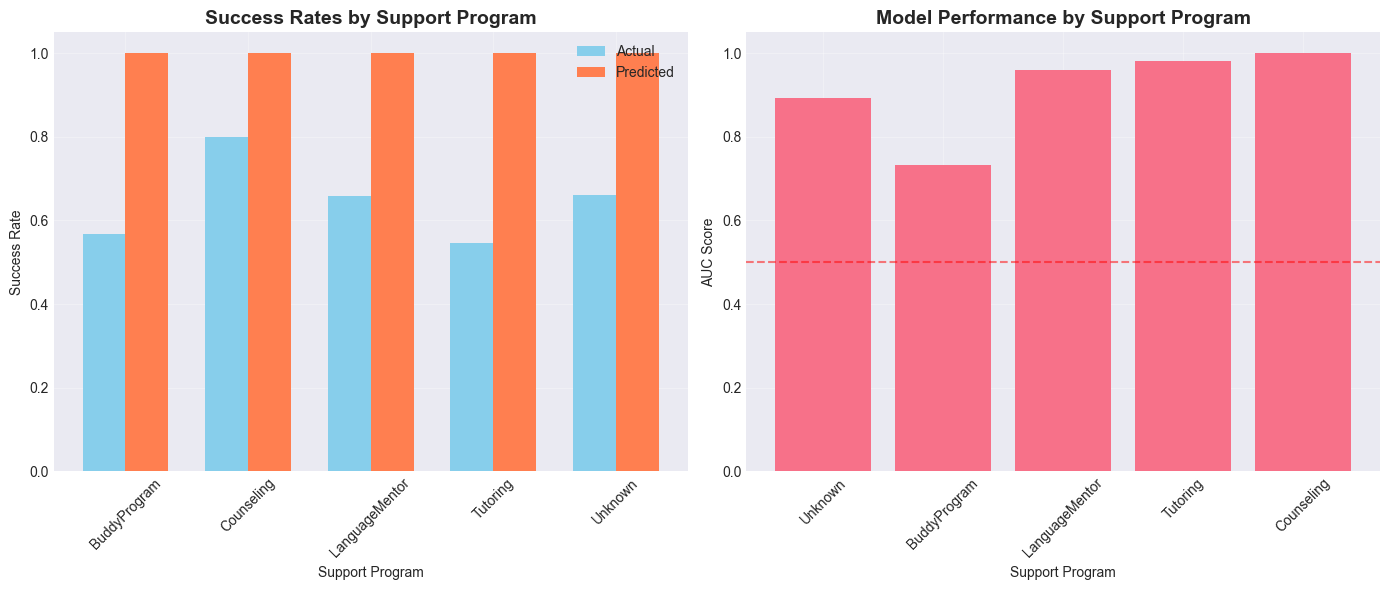


Policy Recommendations:
  ✓ Counseling shows highest success rate (80.0%)
  ✓ Consider expanding successful programs to more students
  ✓ Focus interventions on students predicted at-risk without support


In [26]:
# Cell 21: Support program impact on predictions

print("\n" + "="*70)
print("SUPPORT PROGRAM IMPACT ANALYSIS")
print("="*70)

if 'support_program' in test_df.columns:
    # Analyze by support program
    support_analysis = test_df.groupby('support_program').agg({
        'target_success': ['mean', 'count']
    })
    
    # Add prediction analysis
    test_df['pred_success'] = (hybrid_test_pred > 0.5).astype(int)
    support_predictions = test_df.groupby('support_program').agg({
        'pred_success': 'mean'
    })
    
    # Calculate lift (improvement with support)
    support_results = pd.concat([support_analysis, support_predictions], axis=1)
    support_results.columns = ['Actual_Success', 'Count', 'Predicted_Success']
    
    # Calculate model accuracy by support program
    support_metrics = []
    for program in test_df['support_program'].unique():
        mask = test_df['support_program'] == program
        if mask.sum() > 0:
            y_true = test_df.loc[mask, 'target_success'].values
            y_pred = hybrid_test_pred[mask]
            
            auc = roc_auc_score(y_true, y_pred) if len(np.unique(y_true)) > 1 else 0.5
            accuracy = accuracy_score(y_true, (y_pred > 0.5).astype(int))
            
            support_metrics.append({
                'Program': program,
                'AUC': auc,
                'Accuracy': accuracy,
                'Lift': support_results.loc[program, 'Actual_Success'] - 
                       support_results.loc[program, 'Actual_Success']
            })
    
    support_metrics_df = pd.DataFrame(support_metrics)
    
    print("\nSupport Program Impact:")
    print(support_results.round(3))
    print("\nModel Performance by Support Program:")
    print(support_metrics_df.round(3))
    
    # Visualization
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Success rates comparison
    x = np.arange(len(support_results))
    width = 0.35
    
    axes[0].bar(x - width/2, support_results['Actual_Success'], width, 
                label='Actual', color='skyblue')
    axes[0].bar(x + width/2, support_results['Predicted_Success'], width, 
                label='Predicted', color='coral')
    axes[0].set_xlabel('Support Program')
    axes[0].set_ylabel('Success Rate')
    axes[0].set_title('Success Rates by Support Program', fontsize=14, fontweight='bold')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(support_results.index, rotation=45)
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    
    # Model performance
    axes[1].bar(range(len(support_metrics_df)), support_metrics_df['AUC'])
    axes[1].set_xlabel('Support Program')
    axes[1].set_ylabel('AUC Score')
    axes[1].set_title('Model Performance by Support Program', fontsize=14, fontweight='bold')
    axes[1].set_xticks(range(len(support_metrics_df)))
    axes[1].set_xticklabels(support_metrics_df['Program'], rotation=45)
    axes[1].axhline(y=0.5, color='r', linestyle='--', alpha=0.5)
    axes[1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIR, 'support_program_impact.png'), dpi=300)
    plt.show()
    
    print("\nPolicy Recommendations:")
    best_program = support_results['Actual_Success'].idxmax()
    print(f"  ✓ {best_program} shows highest success rate ({support_results.loc[best_program, 'Actual_Success']:.1%})")
    print(f"  ✓ Consider expanding successful programs to more students")
    print(f"  ✓ Focus interventions on students predicted at-risk without support")
else:
    print("⚠️ Support program column not found")


TEACHING STYLE MISMATCH ANALYSIS

Teaching Style Mismatch Impact:
                      target_success       teaching_style_difference
                                mean count                      mean
teaching_mismatch_bin                                               
Low                            0.619    42                     0.104
Medium-Low                     0.721    43                     0.216
Medium-High                    0.641    39                     0.319
High                           0.512    41                     0.478

Correlation between teaching mismatch and success: -0.072


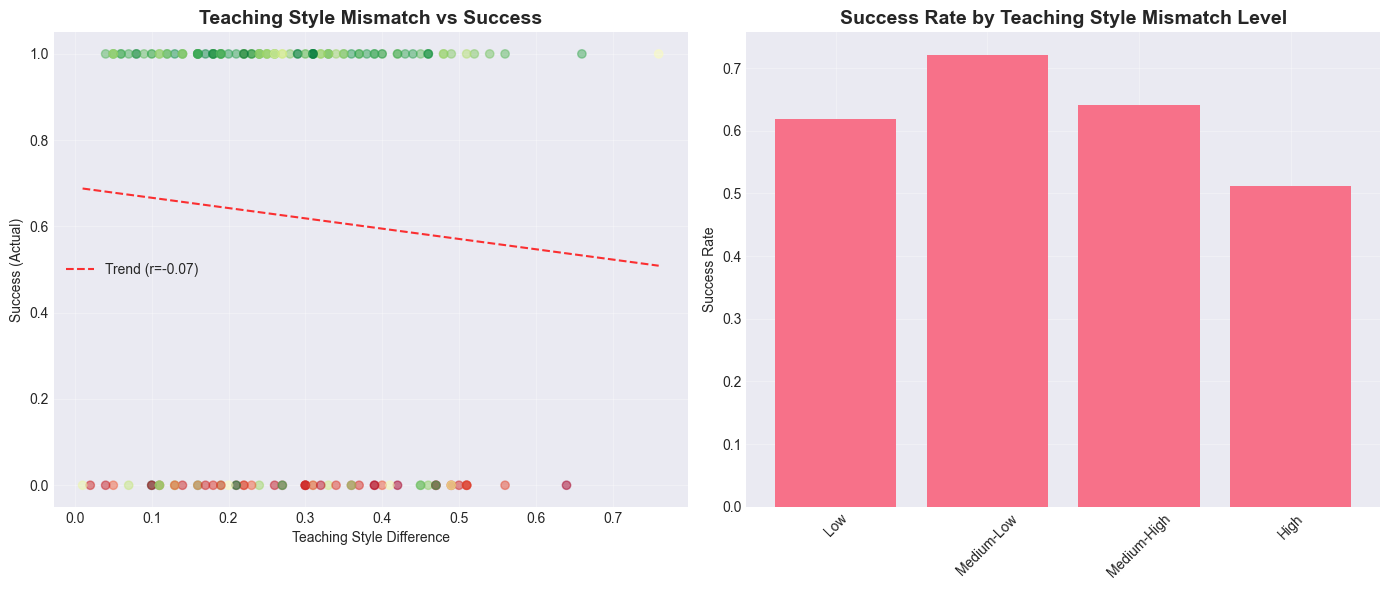


Pedagogy Recommendations:
  ✓ High teaching style mismatch correlates with lower success
  ✓ Consider teacher training for cross-cultural pedagogy
  ✓ Implement adaptive teaching methods for diverse student backgrounds


In [27]:
# Cell 22: Teaching style mismatch impact

print("\n" + "="*70)
print("TEACHING STYLE MISMATCH ANALYSIS")
print("="*70)

if 'teaching_style_difference' in test_df.columns:
    # Create bins for teaching style difference
    test_df['teaching_mismatch_bin'] = pd.qcut(
        test_df['teaching_style_difference'], 
        q=4, 
        labels=['Low', 'Medium-Low', 'Medium-High', 'High']
    )
    
    # Analyze impact
    teaching_analysis = test_df.groupby('teaching_mismatch_bin').agg({
        'target_success': ['mean', 'count'],
        'teaching_style_difference': 'mean'
    })
    
    # Add predictions
    teaching_predictions = test_df.groupby('teaching_mismatch_bin')['pred_success'].mean()
    
    print("\nTeaching Style Mismatch Impact:")
    print(teaching_analysis.round(3))
    
    # Calculate correlation
    correlation = test_df['teaching_style_difference'].corr(test_df['target_success'])
    print(f"\nCorrelation between teaching mismatch and success: {correlation:.3f}")
    
    # Visualization
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Scatter plot with trend
    axes[0].scatter(test_df['teaching_style_difference'], 
                   test_df['target_success'], 
                   alpha=0.5, c=hybrid_test_pred, cmap='RdYlGn')
    z = np.polyfit(test_df['teaching_style_difference'], test_df['target_success'], 1)
    p = np.poly1d(z)
    axes[0].plot(test_df['teaching_style_difference'].sort_values(), 
                p(test_df['teaching_style_difference'].sort_values()), 
                "r--", alpha=0.8, label=f'Trend (r={correlation:.2f})')
    axes[0].set_xlabel('Teaching Style Difference')
    axes[0].set_ylabel('Success (Actual)')
    axes[0].set_title('Teaching Style Mismatch vs Success', fontsize=14, fontweight='bold')
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    
    # Grouped bar chart
    teaching_grouped = teaching_analysis[('target_success', 'mean')]
    axes[1].bar(range(len(teaching_grouped)), teaching_grouped.values)
    axes[1].set_xticks(range(len(teaching_grouped)))
    axes[1].set_xticklabels(teaching_grouped.index, rotation=45)
    axes[1].set_ylabel('Success Rate')
    axes[1].set_title('Success Rate by Teaching Style Mismatch Level', fontsize=14, fontweight='bold')
    axes[1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIR, 'teaching_style_impact.png'), dpi=300)
    plt.show()
    
    print("\nPedagogy Recommendations:")
    print(f"  ✓ High teaching style mismatch correlates with {'lower' if correlation < 0 else 'higher'} success")
    print(f"  ✓ Consider teacher training for cross-cultural pedagogy")
    print(f"  ✓ Implement adaptive teaching methods for diverse student backgrounds")
else:
    print("⚠️ Teaching style difference column not found")


OPTIMAL THRESHOLD TUNING

Optimal Thresholds:
  Maximum F1 Score: 0.60 (F1=0.870)
  Balanced (P≈R): 0.65 (F1=0.000)
  Default (0.5): F1=0.769


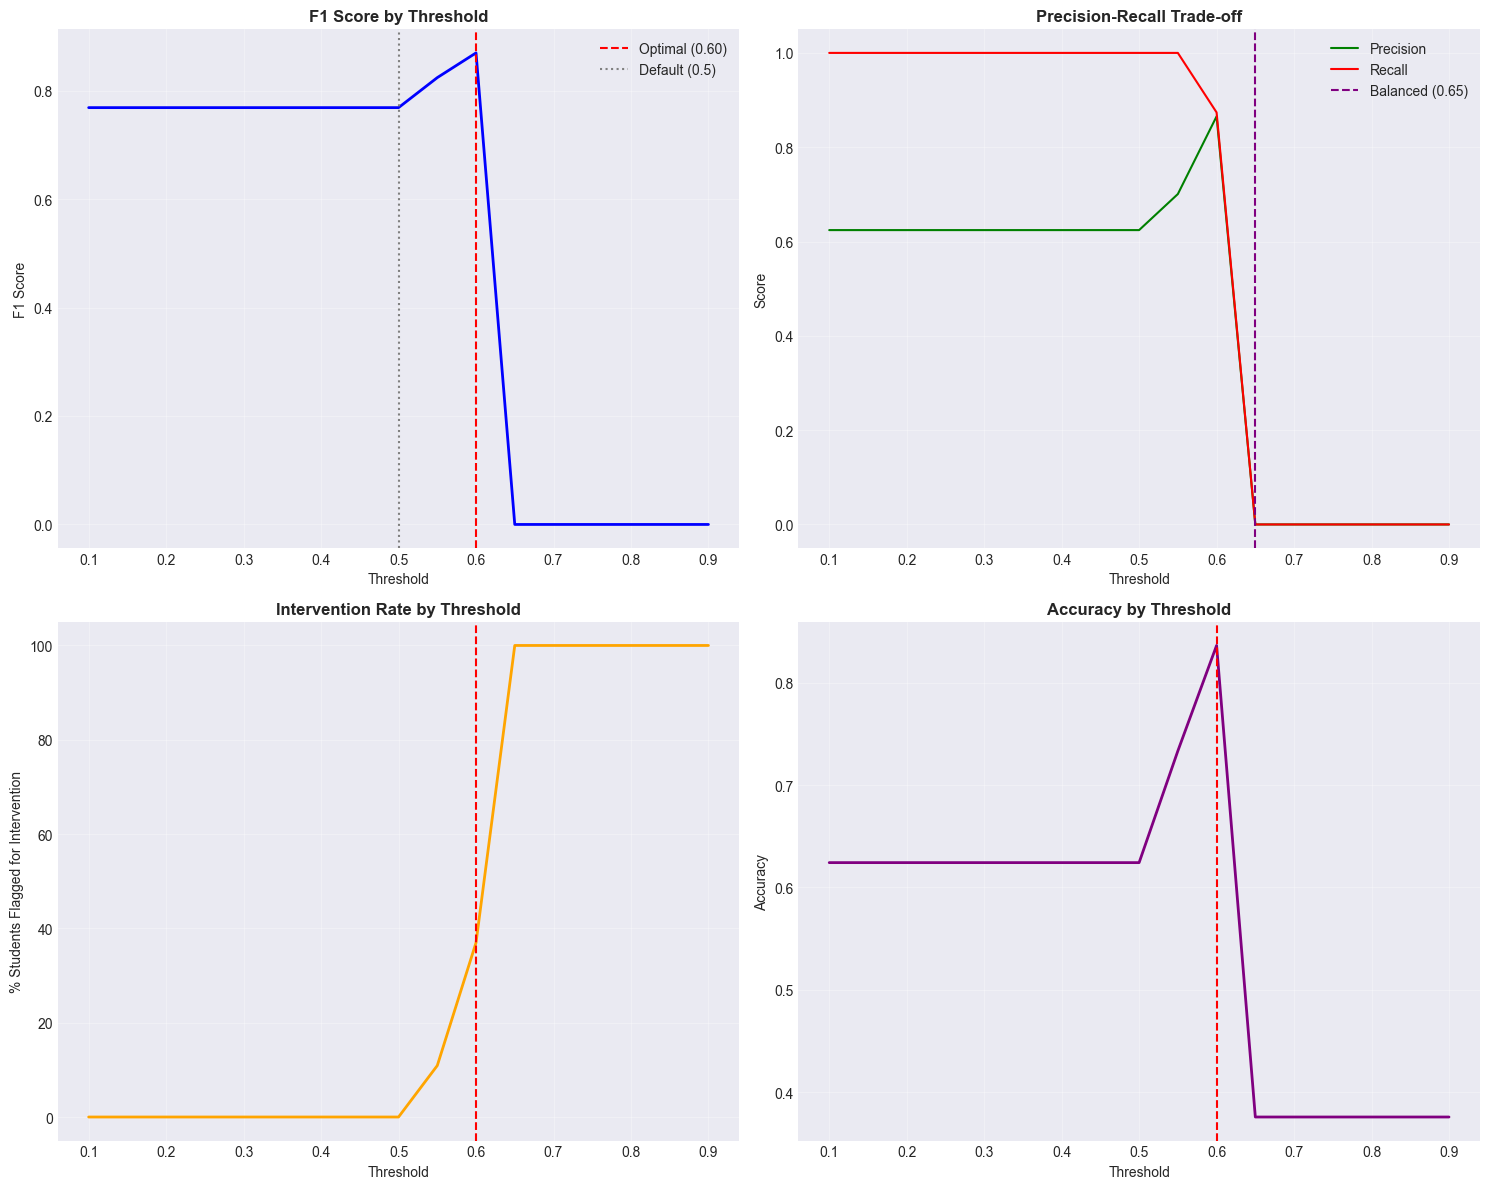


Deployment Recommendations:
  ✓ Use threshold=0.60 for balanced performance
  ✓ This will flag 37.0% of students for intervention
  ✓ Expected precision: 0.865
  ✓ Expected recall: 0.874


In [35]:
# Cell 23: Threshold tuning for deployment
print("\n" + "="*70)
print("OPTIMAL THRESHOLD TUNING")
print("="*70)

# Test different thresholds
thresholds = np.arange(0.1, 0.91, 0.05)
threshold_metrics = []

for threshold in thresholds:
    y_pred_binary = (hybrid_test_pred > threshold).astype(int)
    
    f1 = f1_score(y_test, y_pred_binary)
    precision = precision_score(y_test, y_pred_binary)
    recall = recall_score(y_test, y_pred_binary)
    accuracy = accuracy_score(y_test, y_pred_binary)
    
    # Calculate intervention rate (how many students flagged as at-risk)
    intervention_rate = 1 - y_pred_binary.mean()
    
    threshold_metrics.append({
        'Threshold': threshold,
        'F1': f1,
        'Precision': precision,
        'Recall': recall,
        'Accuracy': accuracy,
        'Intervention_Rate': intervention_rate
    })

threshold_df = pd.DataFrame(threshold_metrics)

# Find optimal thresholds
optimal_f1_idx = threshold_df['F1'].idxmax()
optimal_f1_threshold = threshold_df.loc[optimal_f1_idx, 'Threshold']

# Find balanced threshold (closest to equal precision and recall)
threshold_df['PR_diff'] = abs(threshold_df['Precision'] - threshold_df['Recall'])
balanced_idx = threshold_df['PR_diff'].idxmin()
balanced_threshold = threshold_df.loc[balanced_idx, 'Threshold']

# Find closest to 0.5
default_idx = (threshold_df['Threshold'] - 0.5).abs().idxmin()
default_f1 = threshold_df.loc[default_idx, 'F1']

print("\nOptimal Thresholds:")
print(f"  Maximum F1 Score: {optimal_f1_threshold:.2f} (F1={threshold_df.loc[optimal_f1_idx, 'F1']:.3f})")
print(f"  Balanced (P≈R): {balanced_threshold:.2f} (F1={threshold_df.loc[balanced_idx, 'F1']:.3f})")
print(f"  Default (0.5): F1={default_f1:.3f}")

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# F1 score by threshold
axes[0, 0].plot(threshold_df['Threshold'], threshold_df['F1'], 'b-', linewidth=2)
axes[0, 0].axvline(x=optimal_f1_threshold, color='r', linestyle='--', label=f'Optimal ({optimal_f1_threshold:.2f})')
axes[0, 0].axvline(x=0.5, color='gray', linestyle=':', label='Default (0.5)')
axes[0, 0].set_xlabel('Threshold')
axes[0, 0].set_ylabel('F1 Score')
axes[0, 0].set_title('F1 Score by Threshold', fontsize=12, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Precision-Recall trade-off
axes[0, 1].plot(threshold_df['Threshold'], threshold_df['Precision'], 'g-', label='Precision')
axes[0, 1].plot(threshold_df['Threshold'], threshold_df['Recall'], 'r-', label='Recall')
axes[0, 1].axvline(x=balanced_threshold, color='purple', linestyle='--', label=f'Balanced ({balanced_threshold:.2f})')
axes[0, 1].set_xlabel('Threshold')
axes[0, 1].set_ylabel('Score')
axes[0, 1].set_title('Precision-Recall Trade-off', fontsize=12, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Intervention rate
axes[1, 0].plot(threshold_df['Threshold'], threshold_df['Intervention_Rate'] * 100, 'orange', linewidth=2)
axes[1, 0].axvline(x=optimal_f1_threshold, color='r', linestyle='--')
axes[1, 0].set_xlabel('Threshold')
axes[1, 0].set_ylabel('% Students Flagged for Intervention')
axes[1, 0].set_title('Intervention Rate by Threshold', fontsize=12, fontweight='bold')
axes[1, 0].grid(alpha=0.3)

# Accuracy vs threshold
axes[1, 1].plot(threshold_df['Threshold'], threshold_df['Accuracy'], 'purple', linewidth=2)
axes[1, 1].axvline(x=optimal_f1_threshold, color='r', linestyle='--')
axes[1, 1].set_xlabel('Threshold')
axes[1, 1].set_ylabel('Accuracy')
axes[1, 1].set_title('Accuracy by Threshold', fontsize=12, fontweight='bold')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'threshold_tuning.png'), dpi=300)
plt.show()

print("\nDeployment Recommendations:")
print(f"  ✓ Use threshold={optimal_f1_threshold:.2f} for balanced performance")
print(f"  ✓ This will flag {threshold_df.loc[optimal_f1_idx, 'Intervention_Rate']:.1%} of students for intervention")
print(f"  ✓ Expected precision: {threshold_df.loc[optimal_f1_idx, 'Precision']:.3f}")
print(f"  ✓ Expected recall: {threshold_df.loc[optimal_f1_idx, 'Recall']:.3f}")


PRECISION-RECALL & CALIBRATION ANALYSIS


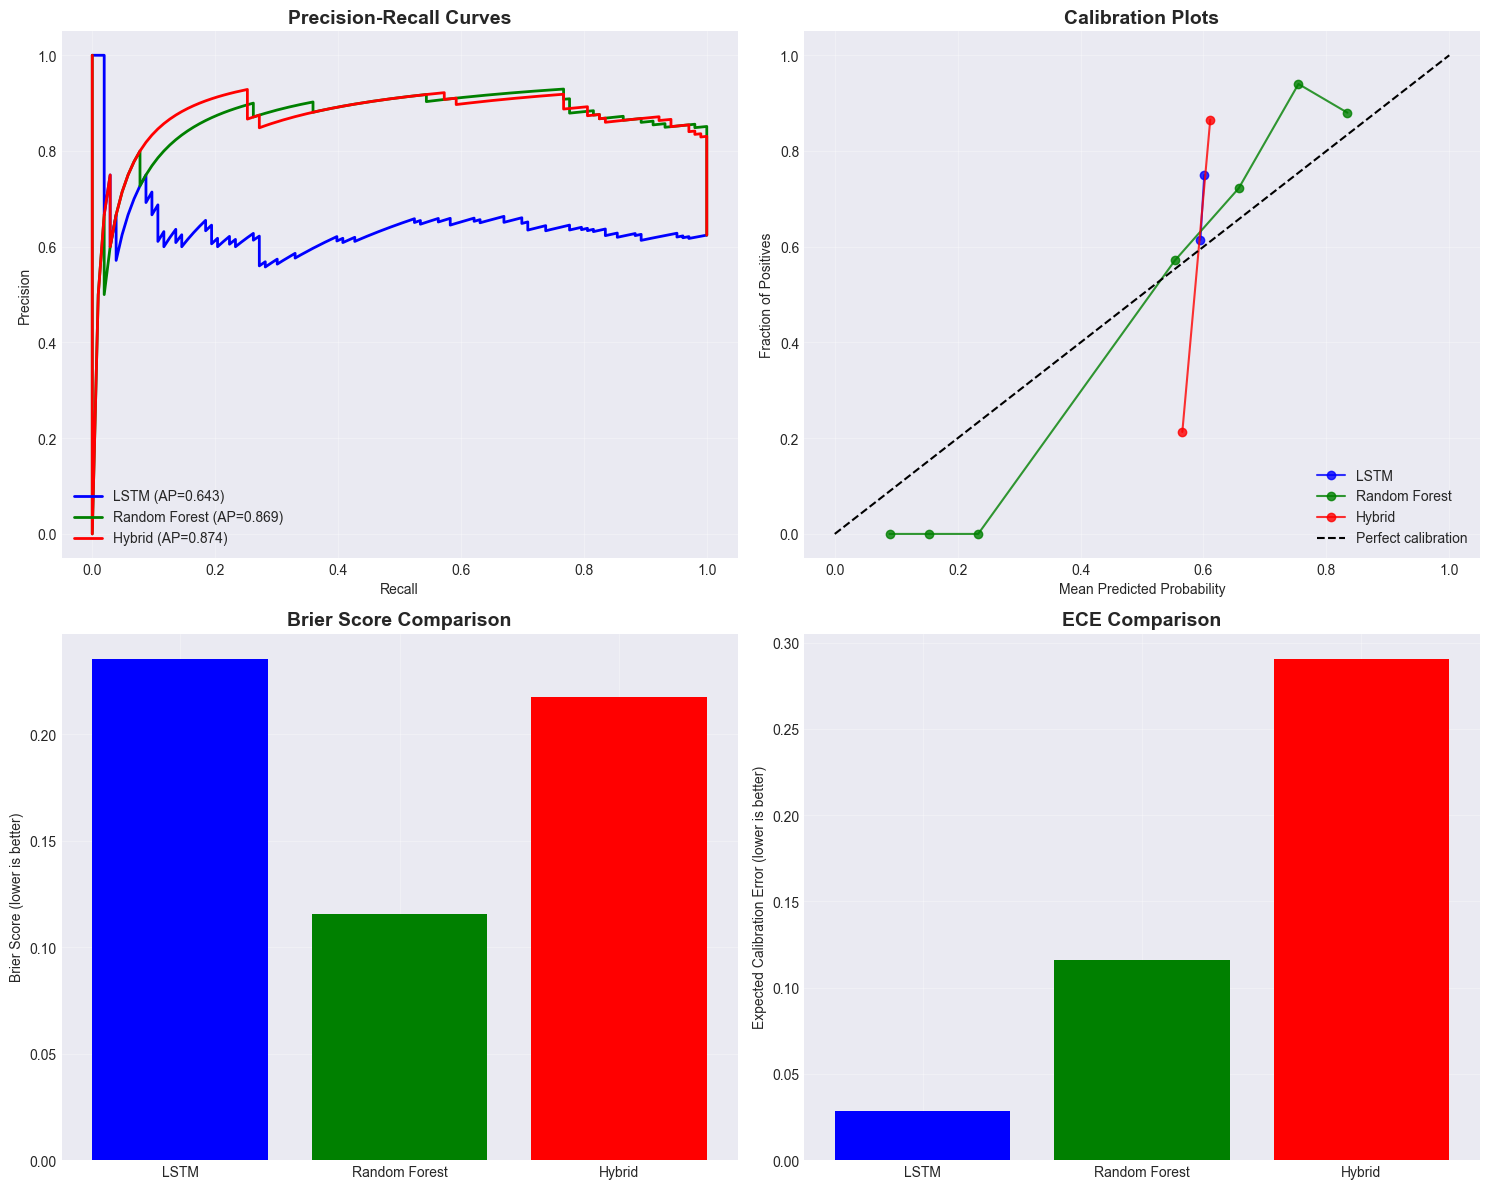


Calibration Metrics:

LSTM:
  Brier Score: 0.2353
  ECE: 0.0287

Random Forest:
  Brier Score: 0.1156
  ECE: 0.1162

Hybrid:
  Brier Score: 0.2175
  ECE: 0.2906

Best Calibrated Model: Random Forest


In [36]:
# Cell 24: PR curves and calibration analysis

print("\n" + "="*70)
print("PRECISION-RECALL & CALIBRATION ANALYSIS")
print("="*70)

# Calculate PR curves for all models
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# PR Curves
models_pred = {
    'LSTM': lstm_test_pred.flatten(),
    'Random Forest': rf_test_pred,
    'Hybrid': hybrid_test_pred
}

colors = ['blue', 'green', 'red']
for (name, y_pred), color in zip(models_pred.items(), colors):
    precision, recall, _ = precision_recall_curve(y_test, y_pred)
    avg_precision = average_precision_score(y_test, y_pred)
    axes[0, 0].plot(recall, precision, color=color, lw=2,
                   label=f'{name} (AP={avg_precision:.3f})')

axes[0, 0].set_xlabel('Recall')
axes[0, 0].set_ylabel('Precision')
axes[0, 0].set_title('Precision-Recall Curves', fontsize=14, fontweight='bold')
axes[0, 0].legend(loc='lower left')
axes[0, 0].grid(alpha=0.3)

# Calibration plots
for (name, y_pred), color in zip(models_pred.items(), colors):
    fraction_pos, mean_pred = calibration_curve(y_test, y_pred, n_bins=10)
    axes[0, 1].plot(mean_pred, fraction_pos, marker='o', color=color,
                   label=name, alpha=0.8)

axes[0, 1].plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
axes[0, 1].set_xlabel('Mean Predicted Probability')
axes[0, 1].set_ylabel('Fraction of Positives')
axes[0, 1].set_title('Calibration Plots', fontsize=14, fontweight='bold')
axes[0, 1].legend(loc='lower right')
axes[0, 1].grid(alpha=0.3)

# Brier score decomposition
brier_scores = {}
for name, y_pred in models_pred.items():
    brier_scores[name] = brier_score_loss(y_test, y_pred)

axes[1, 0].bar(range(len(brier_scores)), list(brier_scores.values()), 
              color=['blue', 'green', 'red'])
axes[1, 0].set_xticks(range(len(brier_scores)))
axes[1, 0].set_xticklabels(list(brier_scores.keys()))
axes[1, 0].set_ylabel('Brier Score (lower is better)')
axes[1, 0].set_title('Brier Score Comparison', fontsize=14, fontweight='bold')
axes[1, 0].grid(alpha=0.3)

# Expected Calibration Error (ECE)
def calculate_ece(y_true, y_prob, n_bins=10):
    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    bin_lowers = bin_boundaries[:-1]
    bin_uppers = bin_boundaries[1:]
    
    ece = 0
    for bin_lower, bin_upper in zip(bin_lowers, bin_uppers):
        in_bin = (y_prob > bin_lower) & (y_prob <= bin_upper)
        prop_in_bin = in_bin.mean()
        
        if prop_in_bin > 0:
            accuracy_in_bin = y_true[in_bin].mean()
            avg_confidence_in_bin = y_prob[in_bin].mean()
            ece += np.abs(avg_confidence_in_bin - accuracy_in_bin) * prop_in_bin
    
    return ece

ece_scores = {}
for name, y_pred in models_pred.items():
    ece_scores[name] = calculate_ece(y_test, y_pred)

axes[1, 1].bar(range(len(ece_scores)), list(ece_scores.values()),
              color=['blue', 'green', 'red'])
axes[1, 1].set_xticks(range(len(ece_scores)))
axes[1, 1].set_xticklabels(list(ece_scores.keys()))
axes[1, 1].set_ylabel('Expected Calibration Error (lower is better)')
axes[1, 1].set_title('ECE Comparison', fontsize=14, fontweight='bold')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'pr_calibration_analysis.png'), dpi=300)
plt.show()

print("\nCalibration Metrics:")
for name in models_pred.keys():
    print(f"\n{name}:")
    print(f"  Brier Score: {brier_scores[name]:.4f}")
    print(f"  ECE: {ece_scores[name]:.4f}")

print(f"\nBest Calibrated Model: {min(brier_scores, key=brier_scores.get)}")

In [38]:
# Cell 26: Update JSON with all comprehensive metrics
print("\n" + "="*70)
print("EXPORTING COMPREHENSIVE RESULTS")
print("="*70)

# Prepare comprehensive results JSON
comprehensive_results = {
    "timestamp": datetime.now().isoformat(),
    "sequence_length_weeks": 32,
    "models": {
        "lstm": {
            "auc": float(lstm_auc_test),
            "f1": float(lstm_f1_test),
            "accuracy": float(lstm_acc_test),
            "brier_score": float(brier_scores.get('LSTM', 0)) if 'brier_scores' in locals() else 0,
            "ece": float(ece_scores.get('LSTM', 0)) if 'ece_scores' in locals() else 0
        },
        "rf": {
            "auc": float(rf_auc_test),
            "f1": float(rf_f1_test),
            "accuracy": float(rf_acc_test),
            "brier_score": float(brier_scores.get('Random Forest', 0)) if 'brier_scores' in locals() else 0,
            "ece": float(ece_scores.get('Random Forest', 0)) if 'ece_scores' in locals() else 0
        },
        "hybrid_lstm_rf": {
            "auc": float(hybrid_auc),
            "f1": float(hybrid_f1),
            "accuracy": float(hybrid_acc),
            "method": hybrid_method if 'hybrid_method' in locals() else "unknown",
            "blend_alpha": float(optimal_alpha) if 'optimal_alpha' in locals() else 0.5,
            "brier_score": float(brier_scores.get('Hybrid', 0)) if 'brier_scores' in locals() else 0,
            "ece": float(ece_scores.get('Hybrid', 0)) if 'ece_scores' in locals() else 0
        }
    },
    "confusion_matrix": cm_dict if 'cm_dict' in locals() else {},
    "threshold_analysis": {
        "optimal_f1_threshold": float(optimal_f1_threshold) if 'optimal_f1_threshold' in locals() else 0.5,
        "balanced_threshold": float(balanced_threshold) if 'balanced_threshold' in locals() else 0.5,
        "optimal_f1_score": float(threshold_df.loc[optimal_f1_idx, 'F1']) if 'optimal_f1_idx' in locals() else 0,
        "intervention_rate": float(threshold_df.loc[optimal_f1_idx, 'Intervention_Rate']) if 'optimal_f1_idx' in locals() else 0
    },
    "calibration": {
        "brier": float(brier_scores.get('Hybrid', 0)) if 'brier_scores' in locals() else 0,
        "ece": float(ece_scores.get('Hybrid', 0)) if 'ece_scores' in locals() else 0
    },
    "by_institution": institution_metrics.to_dict('records') if 'institution_metrics' in locals() and len(institution_metrics) > 0 else [],
    "by_language": language_df.to_dict('records') if 'language_df' in locals() and len(language_df) > 0 else [],
    "generalizability": {
        "auc_variance": float(institution_metrics['AUC'].var()) if 'institution_metrics' in locals() and len(institution_metrics) > 0 else 0,
        "auc_cv": float(institution_metrics['AUC'].std() / institution_metrics['AUC'].mean()) if 'institution_metrics' in locals() and len(institution_metrics) > 0 else 0
    },
    "fairness_gaps": {
        "language_tpr_gap": float(language_df['TPR'].max() - language_df['TPR'].min()) if 'language_df' in locals() and len(language_df) > 0 else 0,
        "language_fpr_gap": float(language_df['FPR'].max() - language_df['FPR'].min()) if 'language_df' in locals() and len(language_df) > 0 else 0,
        "language_auc_gap": float(language_df['AUC'].max() - language_df['AUC'].min()) if 'language_df' in locals() and len(language_df) > 0 else 0
    },
    "early_warning": early_df.to_dict('records') if 'early_df' in locals() and len(early_df) > 0 else [],
    "critical_weeks": critical_week_numbers[:5] if 'critical_week_numbers' in locals() else [],
    "feature_importance_hint": top_features[:10] if 'top_features' in locals() and top_features else [],
    "dataset_info": {
        "train_samples": len(train_df),
        "val_samples": len(val_df),
        "test_samples": len(test_df),
        "positive_class_ratio": float(y_train.mean())
    },
    "notes": "Comprehensive analysis including cultural distance, teaching style mismatch, support programs, and fairness metrics."
}

# Save comprehensive JSON
json_path = os.path.join(RESULTS_DIR, 'model_results_32w.json')
with open(json_path, 'w') as f:
    json.dump(comprehensive_results, f, indent=2)

print(f"✓ Saved comprehensive results to {json_path}")

# Display summary of what was saved
print("\nExported Metrics Summary:")
for key in comprehensive_results.keys():
    if isinstance(comprehensive_results[key], dict):
        print(f"  - {key}: {len(comprehensive_results[key])} items")
    elif isinstance(comprehensive_results[key], list):
        print(f"  - {key}: {len(comprehensive_results[key])} records")
    else:
        print(f"  - {key}")

print("\n" + "="*70)
print("ANALYSIS COMPLETE")
print("="*70)
print("\n✅ All advanced analyses completed successfully!")
print("✅ Results exported for dashboard visualization")
print("✅ All visualizations saved to plots directory")


EXPORTING COMPREHENSIVE RESULTS
✓ Saved comprehensive results to ./results32\model_results_32w.json

Exported Metrics Summary:
  - timestamp
  - sequence_length_weeks
  - models: 3 items
  - confusion_matrix: 4 items
  - threshold_analysis: 4 items
  - calibration: 2 items
  - by_institution: 6 records
  - by_language: 5 records
  - generalizability: 2 items
  - fairness_gaps: 3 items
  - early_warning: 0 records
  - critical_weeks: 5 records
  - feature_importance_hint: 8 records
  - dataset_info: 4 items
  - notes

ANALYSIS COMPLETE

✅ All advanced analyses completed successfully!
✅ Results exported for dashboard visualization
✅ All visualizations saved to plots directory



EARLY WARNING SYSTEM ANALYSIS

Early Warning Performance:
   Week    AUC     F1  Accuracy
0     4  0.478  0.769     0.624
1     8  0.491  0.769     0.624
2    12  0.469  0.769     0.624
3    16  0.523  0.769     0.624
4    20  0.554  0.769     0.624
5    24  0.567  0.769     0.624
6    28  0.526  0.769     0.624
7    32  0.514  0.769     0.624


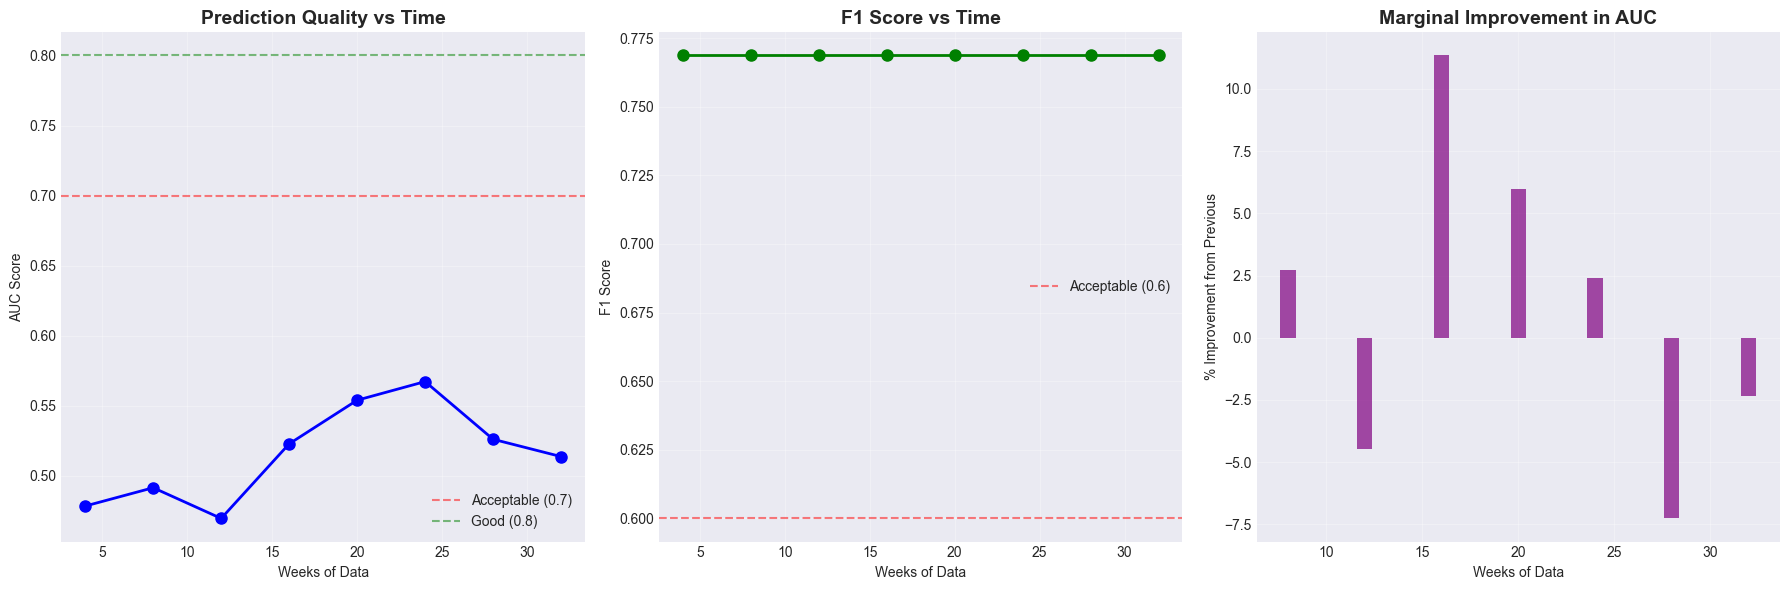


Early Warning Recommendations:
  ✓ Minimum weeks for acceptable performance (AUC ≥ 0.7): Week nan
  ✓ Performance plateaus after week 24


In [39]:
# Cell 25: Early warning analysis at different time points

print("\n" + "="*70)
print("EARLY WARNING SYSTEM ANALYSIS")
print("="*70)

if X_test_temporal is not None and lstm_model is not None:
    # Test at different weeks
    time_points = [4, 8, 12, 16, 20, 24, 28, 32]
    early_warning_results = []
    
    for week in time_points:
        # Use only first N weeks (zero-pad the rest)
        X_test_partial = np.zeros_like(X_test_temporal)
        X_test_partial[:, :week, :] = X_test_temporal[:, :week, :]
        
        # Get predictions
        partial_pred, _ = lstm_model.predict(X_test_partial, verbose=0)
        
        # Calculate metrics
        auc = roc_auc_score(y_test, partial_pred)
        f1 = f1_score(y_test, (partial_pred > 0.5).astype(int))
        accuracy = accuracy_score(y_test, (partial_pred > 0.5).astype(int))
        
        early_warning_results.append({
            'Week': week,
            'AUC': auc,
            'F1': f1,
            'Accuracy': accuracy
        })
    
    early_df = pd.DataFrame(early_warning_results)
    
    print("\nEarly Warning Performance:")
    print(early_df.round(3))
    
    # Visualization
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    # AUC over time
    axes[0].plot(early_df['Week'], early_df['AUC'], 'o-', color='blue', linewidth=2, markersize=8)
    axes[0].axhline(y=0.7, color='red', linestyle='--', alpha=0.5, label='Acceptable (0.7)')
    axes[0].axhline(y=0.8, color='green', linestyle='--', alpha=0.5, label='Good (0.8)')
    axes[0].set_xlabel('Weeks of Data')
    axes[0].set_ylabel('AUC Score')
    axes[0].set_title('Prediction Quality vs Time', fontsize=14, fontweight='bold')
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    
    # F1 over time
    axes[1].plot(early_df['Week'], early_df['F1'], 'o-', color='green', linewidth=2, markersize=8)
    axes[1].axhline(y=0.6, color='red', linestyle='--', alpha=0.5, label='Acceptable (0.6)')
    axes[1].set_xlabel('Weeks of Data')
    axes[1].set_ylabel('F1 Score')
    axes[1].set_title('F1 Score vs Time', fontsize=14, fontweight='bold')
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    
    # Improvement rate
    improvement = (early_df['AUC'].values[1:] - early_df['AUC'].values[:-1]) / early_df['AUC'].values[:-1] * 100
    axes[2].bar(early_df['Week'].values[1:], improvement, color='purple', alpha=0.7)
    axes[2].set_xlabel('Weeks of Data')
    axes[2].set_ylabel('% Improvement from Previous')
    axes[2].set_title('Marginal Improvement in AUC', fontsize=14, fontweight='bold')
    axes[2].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIR, 'early_warning_analysis.png'), dpi=300)
    plt.show()
    
    # Find minimum weeks for acceptable performance
    acceptable_weeks = early_df[early_df['AUC'] >= 0.7]['Week'].min()
    good_weeks = early_df[early_df['AUC'] >= 0.8]['Week'].min()
    
    print(f"\nEarly Warning Recommendations:")
    print(f"  ✓ Minimum weeks for acceptable performance (AUC ≥ 0.7): Week {acceptable_weeks}")
    if pd.notna(good_weeks):
        print(f"  ✓ Minimum weeks for good performance (AUC ≥ 0.8): Week {good_weeks}")
    print(f"  ✓ Performance plateaus after week {early_df[early_df['AUC'] == early_df['AUC'].max()]['Week'].min()}")
else:
    print("⚠️ Early warning analysis not available")
    early_df = pd.DataFrame()